<a href="https://colab.research.google.com/github/tomizurro/UA_MDM_Labo2/blob/main/TP2_soja_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N° 2 — Análisis de Series Temporales
### Modelado y pronóstico con Machine Learning, Deep Learning, modelos híbridos y modelos fundacionales**Maestría en Ciencia de Datos — Universidad Austral

**Continuación del TP1 sobre las tres series semanales del complejo soja del Gran Rosario:| | Serie | Unidad | Agregación semanal ||---|---|---|---||**

**S1** | Ingreso de soja por transporte automotor | toneladas | **suma** ||

**S2** | Comercialización de soja con destino Rosario | toneladas | **suma** ||

**S3** | Precio doméstico de la soja | USD/t | **promedio** |---
## Qué compara este trabajo
El TP1 estableció que las tres series forman un sistema: la comercialización precede al ingreso físico y explica cerca del 30 % de la varianza de su error de pronóstico a trece semanas. Elmodelado allí fue lineal —SARIMA univariado y VAR—. Este trabajo pregunta si las familias no lineales de aprendizaje automático mejoran ese resultado, y bajo qué condiciones.La comparación se organiza en **ocho familias**, no en una lista plana de modelos:| Familia | Modelos | Qué aporta ||---|---|---||

**A. Benchmarks ingenuos** | Naive, Seasonal Naive, Drift, Theta, Holt-Winters | Cota inferior. Sin ellos ninguna métrica es interpretable. ||

**B. Clásicos del TP1** | ARIMA + Fourier, SARIMA(m=52) | Puente con el trabajo anterior. ||

**C. Multivariado clásico** | **VAR**, **VARX** | El sistema completo, como en el TP1. ||

**D. ML tabular univariado** | LightGBM, XGBoost, CatBoost | Rezagos y exógenas en formato supervisado. ||

**E. ML multivariado** | **skforecast Direct MultiVariate** | El análogo no lineal del VAR: rezagos de las tres series predicen cada una. ||

**F. Deep learning** | N-BEATS, N-HiTS, TSMixer, TiDE, LSTM, DLinear | Redes especializadas, con covariables pasadas y futuras. ||

**F'. DL multivariado y global** | TSMixer-MV, TiDE-MV, N-HiTS-Global | Un solo modelo para las tres series, en dos variantes conceptualmente distintas. ||

**G. Híbridos** | Prophet, **ARIMA-Fourier + LightGBM sobre residuos** | Descomposición aditiva y corrección no lineal del modelo lineal. ||

**H. Modelos fundacionales** | **Chronos-T5**, **Chronos-Bolt** | Pronóstico *zero-shot*, sin entrenamiento sobre estos datos. ||

**I. AutoML** | AutoGluon TimeSeries | Búsqueda automática y ensamble ponderado. ||

**J. Ensambles** | Media top-3, mediana, **stacking NNLS** | Combinación de los pronósticos anteriores. |

## Sobre "multivariado": tres sentidos distintos

La palabra se usa con tres significados que este trabajo mantiene separados, porque no sonintercambiables y la comparación pierde sentido si se los confunde:

1. **Univariado con covariables exógenas.** Se modela una serie; las otras dos entran como   regresores. La ecuación es una sola. Es lo que hacen LightGBM, N-BEATS o TiDE en la familia D/F.

2. **Multivariado propiamente dicho (sistema).** Se modelan las tres series **conjuntamente**, con   una ecuación por variable y realimentación entre ellas. Es el VAR del TP1 y, en versión no   lineal, `ForecasterDirectMultiVariate` y los modelos DL con objetivo de tres componentes.

3. **Global (panel).** Un único conjunto de parámetros entrenado sobre las tres series tratadas   como realizaciones del mismo proceso. No hay realimentación, pero sí transferencia de   información: el modelo ve el triple de datos. Es el paradigma de los modelos fundacionales.

## Diseño experimental-

**Horizonte** `H = 13` semanas (un trimestre), igual al del pronóstico ex ante del TP1.-

**Escala** logarítmica, la misma del TP1, de modo que los RMSE son comparables entre trabajos.-

**Validación** de ventana expandida con `N_PLIEGUES = 8` orígenes separados por 13 semanas  (104 semanas de validación), con reajuste completo del modelo en cada origen.-

**Hold-out** final de 13 semanas, nunca visto por ningún ajuste ni por ninguna decisión.- **Métricas** RMSE, MAE, MAPE y

**MASE**, en logaritmos y en niveles, más el *skill score* contra  el ingenuo estacional y el contraste de

**Diebold-Mariano** para decidir si las diferencias entre  modelos son estadísticamente distinguibles o ruido muestral.>

**Tiempo de ejecución:** del orden de **2 a 3 horas con GPU** (T4 de Colab) para la corrida> completa. `MODO_RAPIDO = True` la reduce a unos 25 minutos con menos pliegues y menos épocas.> Todos los pronósticos se cachean en Drive, de modo que una interrupción no obliga a recomenzar.

## 0. Configuración
### 0.1 Dependencias
Dos bloques deliberadamente separados. El primero instala el stack principal. El segundo,AutoGluon, va **al final del cuaderno** y en una sesión aparte: reemplaza versiones de `torch` y`pytorch-lightning` y rompe la instalación de Darts. Como todos los pronósticos quedan cacheadosen disco, ejecutarlo después no obliga a recalcular nada.> Al terminar, esta celda **reinicia el kernel automáticamente**. Es lo correcto: la instalación> reemplaza `numpy` y el intérprete debe volver a cargarlo desde cero. Después del reinicio,> continuar desde la celda siguiente sin volver a instalar.

In [ ]:
# statsmodels queda acotado a la rama 0.14: en 0.15 cambia la firma interna de
# ExponentialSmoothing y los modelos Theta de Darts fallan con
# "initialization_method must be a string".
%pip install -q "u8darts[torch]>=0.30" lightgbm xgboost catboost prophet \
                "skforecast>=0.14" optuna "chronos-forecasting" \
                "statsmodels>=0.14,<0.15"

# La instalacion reemplaza numpy y pyarrow; el kernel debe recargarlos desde cero.
# Sin este reinicio, el import de darts falla con un AttributeError de numpy.
import IPython
IPython.get_ipython().kernel.do_shutdown(True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.5/744.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.7/529.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

{'status': 'ok', 'restart': True}

In [ ]:
import os
import gc
import json
import time
import pickle
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.optimize import nnls

import torch

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import (
    NaiveSeasonal, NaiveDrift, Theta, FourTheta, ExponentialSmoothing,
    LightGBMModel, XGBModel, CatBoostModel,
    NBEATSModel, NHiTSModel, TSMixerModel, TiDEModel, BlockRNNModel, DLinearModel,
    Prophet,
)
from darts.utils.utils import SeasonalityMode

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR

warnings.simplefilter("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

print("darts OK | torch", torch.__version__, "| GPU:", torch.cuda.is_available())

darts OK | torch 2.11.0+cu128 | GPU: True


### 0.2 Rutas y constantesÚnico bloque a editar. Las rutas replican las del TP1.

**Elección de `H = 13` y del hold-out.** Fijar el horizonte de pronóstico y la longitud del hold-out en el mismo valor no es una comodidad: permite entrenar cada red con`output_chunk_length = H` y obtener el pronóstico completo en **un solo paso** (*directmulti-step*). La alternativa recursiva —predecir un paso, realimentarlo y repetir— acumula error y, peor, exige covariables pasadas posteriores al origen del pronóstico, que en operación real n existen. Trece semanas equivalen además a un trimestre, la ventana del pronóstico ex ante del TP1.

**Elección de `N_PLIEGUES = 8`.** Con 8 orígenes separados por 13 semanas, la validación cubre 104 semanas —dos ventanas de cosecha completas— y cada modelo se evalúa sobre 104 puntos en lugar de 13. Es la diferencia entre estimar el error de generalización y observar una realización suya.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
XLSX = "/content/drive/MyDrive/Series_Temporales/Series.xlsx"
OUT  = "/content/drive/MyDrive/Series_Temporales/out_tp2"
FIGS = "/content/drive/MyDrive/Series_Temporales/figs_tp2"
os.makedirs(OUT, exist_ok=True)
os.makedirs(FIGS, exist_ok=True)

M     = 52                 # periodo estacional (semanas por ano)
FREQ  = "W-SUN"            # semanas calendario con cierre domingo
H     = 13                 # horizonte de pronostico = longitud del hold-out
N_PLIEGUES = 8             # origenes de validacion de ventana expandida
ICL   = 52                 # input_chunk_length de las redes: un ano de contexto
SEED  = 42

MODO_RAPIDO    = False     # True: 3 pliegues, menos epocas, modelos chicos
CORRER_SARIMA  = True      # SARIMA(m=52) del TP1: ~1 min por ajuste
CORRER_TFT     = False     # Temporal Fusion Transformer: duplica el tiempo del bloque DL
CHRONOS_MODELO = "amazon/chronos-t5-base"       # tiny | mini | small | base | large
BOLT_MODELO    = "amazon/chronos-bolt-base"

EPOCAS = 15 if MODO_RAPIDO else 60
if MODO_RAPIDO:
    N_PLIEGUES, CORRER_SARIMA = 3, False

SERIES = {
    "S1": dict(hoja="Camiones",         col="camiones",         agg="sum",
               etiq="S1 - Ingreso de soja por camion",  unidad="t/semana"),
    "S2": dict(hoja="Comercializacion", col="comercializacion", agg="sum",
               etiq="S2 - Comercializacion de soja",    unidad="t/semana"),
    "S3": dict(hoja="Precios",          col="precio",           agg="mean",
               etiq="S3 - Precio domestico de la soja", unidad="USD/t"),
}
COLS = [v["col"] for v in SERIES.values()]
SID_DE_COL = {v["col"]: k for k, v in SERIES.items()}

np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
AZUL, ROJO, VERDE, GRIS = "#1f4e79", "#c00000", "#2e7d32", "#7f7f7f"
PALETA = ["#1f4e79", "#c00000", "#2e7d32", "#e07b00", "#6a3d9a", "#00838f",
          "#8d6e63", "#b5179e", "#4a5568", "#7cb342", "#d81b60", "#0277bd"]

print(f"H={H} | pliegues={N_PLIEGUES} | epocas={EPOCAS} | rapido={MODO_RAPIDO} "
      f"| SARIMA={CORRER_SARIMA} | Chronos={CHRONOS_MODELO}")

H=13 | pliegues=8 | epocas=60 | rapido=False | SARIMA=True | Chronos=amazon/chronos-t5-base


## 1. Carga, agregación semanal y limpieza defensiva
Se reproduce el preprocesamiento del TP1, cuya justificación se desarrolló allí:
1. Del libro se toma **solo la columna `Soja`** de las hojas `Camiones`, `Comercializacion` y   `Precios`.
2. Los **ceros de S3 se reclasifican como faltantes** antes de promediar: un precio nulo significa   "no hubo rueda", no un precio de cero, y sesgaría el promedio semanal a la baja. Los ceros de   S1 y S2 sí son informativos —jornada sin actividad— y se conservan.
3. **Agregación semanal** (W-SUN): suma para los flujos, promedio para el precio. Elimina el efecto calendario de período 7 documentado en el TP1, que de otro modo obligaría a modelar estacionalidad múltiple.
4. Se recorta al período común y se descartan las semanas truncadas de los extremos.

In [ ]:
def leer_hoja(hoja):
    '''Lee una hoja del libro y devuelve la serie diaria de soja, ordenada y sin duplicados.'''
    df = pd.read_excel(XLSX, sheet_name=hoja)
    df = df.rename(columns={df.columns[0]: "fecha"})
    df["fecha"] = pd.to_datetime(df["fecha"])
    s = df.set_index("fecha")["Soja"].astype(float).sort_index()
    return s[~s.index.duplicated(keep="first")]


diario = {sid: leer_hoja(cfg["hoja"]) for sid, cfg in SERIES.items()}
diario["S3"] = diario["S3"].replace(0.0, np.nan)      # precio cero == sin rueda

sem = {}
for sid, cfg in SERIES.items():
    s = diario[sid]
    # min_count=1 evita que una semana sin ningun dato se convierta en 0 por la suma
    sem[sid] = (s.resample(FREQ).sum(min_count=1) if cfg["agg"] == "sum"
                else s.resample(FREQ).mean())

panel = pd.concat({SERIES[k]["col"]: v for k, v in sem.items()}, axis=1)

ini = max(s.index.min() for s in diario.values())
fin = min(s.index.max() for s in diario.values())
prim_lunes  = ini + pd.Timedelta(days=(7 - ini.weekday()) % 7)
ult_domingo = fin - pd.Timedelta(days=(fin.weekday() + 1) % 7)
panel = panel.loc[(panel.index >= prim_lunes + pd.Timedelta(days=6)) &
                  (panel.index <= ult_domingo)].asfreq(FREQ)

print("Faltantes semanales antes de imputar:")
print(panel.isna().sum().to_string())

panel["precio"] = panel["precio"].interpolate(limit=3, limit_direction="both")
panel[["camiones", "comercializacion"]] = panel[["camiones", "comercializacion"]].fillna(0.0)
assert panel.notna().all().all()

panel.to_csv(f"{OUT}/panel_semanal.csv")
print(f"\nPanel semanal: {panel.shape[0]} semanas, "
      f"{panel.index.min().date()} a {panel.index.max().date()}")
panel.tail(3)

Faltantes semanales antes de imputar:
camiones            0
comercializacion    0
precio              0

Panel semanal: 602 semanas, 2015-01-11 a 2026-07-19


,camiones,comercializacion,precio
fecha,,,
2026-07-05,473300.0,739201.96,321.913354
2026-07-12,459829.0,439999.28,324.812214
2026-07-19,485112.0,699690.02,334.060146


### 1.1 Transformación logarítmica
El TP1 estimó por máxima verosimilitud el parámetro de Box-Cox en **0,307** y **0,121** para S1 yS2, valores próximos a cero que justifican el **logaritmo**: estabiliza la varianza —ambas series exhiben amplitud creciente con el nivel— y convierte los errores en aproximadamente porcentuales.En S3 la estimación arroja **λ = −1,054**, pero se adopta igualmente el logaritmo porque la primera diferencia de la serie logarítmica es el rendimiento semanal, magnitud con interpretación económica directa, y porque mantener una escala común en las tres series es condición para que las métricas resulten comparables entre ellas.El logaritmo no está definido en el cero de S1 de la semana central del **paro aceitero-portuario de diciembre de 2020**. Esa observación se interpola linealmente en logaritmos: sustituirla por unvalor arbitrario pequeño introduciría un atípico de unas diez unidades logarítmicas que dominaríala función de pérdida de cualquier red. La condición de semana intervenida se preserva mediante las indicadoras de la sección 2.2.

In [ ]:
log_panel = np.log(panel.replace(0, np.nan))
log_panel.columns = [f"l{c}" for c in COLS]

n_interp = log_panel.isna().sum()
log_panel = log_panel.interpolate(limit_direction="both")
assert log_panel.notna().all().all()
log_panel.to_csv(f"{OUT}/panel_log.csv")

print("Observaciones interpoladas (ceros originales):")
print(n_interp.to_string())

# --- Diagnostico de extremos: todo outlier debe tener nombre institucional
z = (log_panel - log_panel.mean()) / log_panel.std()
ext = z[(z.abs() > 3.5).any(axis=1)]
print(f"\nSemanas con |z| > 3,5 en alguna serie: {len(ext)}")
print(pd.concat([panel.loc[ext.index].round(0), ext.round(2).add_prefix("z_")], axis=1))

Observaciones interpoladas (ceros originales):
lcamiones            1
lcomercializacion    0
lprecio              0

Semanas con |z| > 3,5 en alguna serie: 2
            camiones  comercializacion  precio  z_lcamiones  z_lcomercializacion  z_lprecio
fecha                                                                                      
2020-12-20      31.0          344600.0   335.0       -12.79                -0.97       0.77
2020-12-27       0.0          296254.0   337.0        -8.02                -1.25       0.81


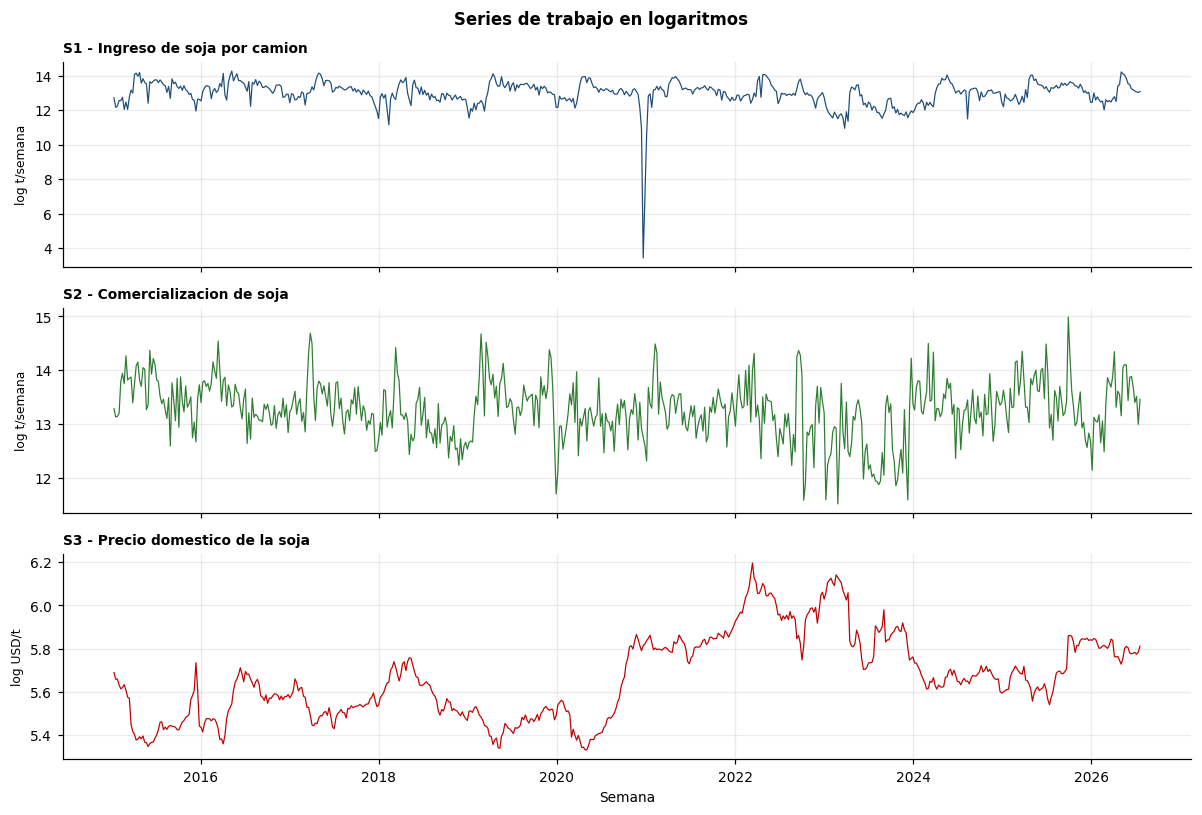

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
for ax, (sid, cfg), color in zip(axes, SERIES.items(), [AZUL, VERDE, ROJO]):
    ax.plot(log_panel.index, log_panel[f"l{cfg['col']}"], lw=.8, color=color)
    ax.set_ylabel("log " + cfg["unidad"], fontsize=8)
    ax.set_title(cfg["etiq"], loc="left", fontsize=9, fontweight="bold")
axes[-1].set_xlabel("Semana")
fig.suptitle("Series de trabajo en logaritmos", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIGS}/fig01_series_log.png", bbox_inches="tight")
plt.show()

## 2. Ingeniería de características
Darts obliga a declarar explícitamente si una covariable es **pasada** —observable solo hasta el origen del pronóstico— o **futura** —conocida de antemano para todo el horizonte—. Esa distinciónes la salvaguarda estructural contra la fuga de información, y este trabajo la respeta también en los modelos que no la imponen (skforecast, statsmodels).
- **Futuras:** el calendario y las indicadoras de intervención de eventos ya observados.
- **Pasadas:** las otras dos series del sistema y las estadísticas móviles de la propia serie.Los rezagos de la variable objetivo los administra cada modelo con su parámetro `lags` o su`input_chunk_length`, de modo que la construcción de la matriz de diseño queda del lado de lalibrería y no admite desalineaciones manuales.

### 2.1 Calendario (covariables futuras)

El índice se **extiende `H` semanas** para que las covariables futuras cubran el horizonte también en la corrida ex ante final.
- **Codificación cíclica** (seno/coseno) de mes y semana del año: evita la discontinuidad  artificial entre la semana 52 y la 1 que introduciría una codificación entera.
- **Armónicos de Fourier** de período 52 con `K = 3` pares: la representación paramétrica de la  estacionalidad anual que el TP1 encontró superior en AIC al rezago estacional de orden 52, con  seis columnas en lugar de 51 indicadoras.
- **Tendencia normalizada** en `[0, 1]`: deriva de largo plazo acotada, para que la extrapolación  al horizonte no se dispare.
- **Ventana de cosecha** (semanas 14 a 27): indicadora de dominio. El grueso del ingreso y de la  comercialización se concentra allí; dar la explícita alivia al modelo de reconstruirla desde los armónicos.

In [ ]:
idx_ext = pd.date_range(start=log_panel.index[0], periods=len(log_panel) + H, freq=FREQ)

def construir_calendario(idx):
    '''Covariables futuras deterministas: ciclicas, Fourier(52), tendencia y cosecha.'''
    t = np.arange(len(idx))
    df = pd.DataFrame(index=idx)
    woy = idx.isocalendar().week.to_numpy().astype(float)
    mes = idx.month.to_numpy().astype(float)
    df["woy_sin"] = np.sin(2 * np.pi * woy / 52.18)
    df["woy_cos"] = np.cos(2 * np.pi * woy / 52.18)
    df["mes_sin"] = np.sin(2 * np.pi * mes / 12)
    df["mes_cos"] = np.cos(2 * np.pi * mes / 12)
    for k in range(1, 4):                       # K = 3 pares de armonicos
        df[f"fs{k}"] = np.sin(2 * np.pi * k * t / M)
        df[f"fc{k}"] = np.cos(2 * np.pi * k * t / M)
    df["trimestre"] = idx.quarter.to_numpy().astype(float)
    df["tendencia"] = t / len(idx)
    df["cosecha"]   = ((woy >= 14) & (woy <= 27)).astype(float)
    return df

calendario = construir_calendario(idx_ext)
print(f"Calendario: {calendario.shape[0]} semanas x {calendario.shape[1]} columnas "
      f"(hasta {calendario.index[-1].date()})")
calendario.tail(2).round(3)

Calendario: 615 semanas x 13 columnas (hasta 2026-10-18)


,woy_sin,woy_cos,mes_sin,mes_cos,fs1,fc1,fs2,fc2,fs3,fc3,trimestre,tendencia,cosecha
2026-10-11,-0.975,0.223,-0.866,0.5,-0.971,0.239,-0.465,-0.885,0.749,-0.663,4.0,0.997,0.0
2026-10-18,-0.941,0.338,-0.866,0.5,-0.935,0.355,-0.663,-0.749,0.465,-0.885,4.0,0.998,0.0


### 2.2 Indicadoras de intervención

Las fechas provienen del TP1. La regla que evita la fuga es estricta: **una indicadora se incorpora solo si su evento cae dentro del tramo de entrenamiento del pliegue**. Una dummy cuyo evento ocurre en validación o en test no es identificable con la información disponible en el origen y usarla equivaldría a suponer conocido un anuncio de política antes de que ocurriera. El filtro se aplica dentro del motor de ajuste, no aquí. Con el hold-out en las últimas 13 semanas, la venta extraordinaria del 28 de septiembre de 2025 —asociada a la baja transitoria de derechos de exportación— queda fuera del entrenamiento en los primeros pliegues y se incorpora recién en los últimos. Ese comportamiento es deseable: reproduce la situación real de un analista que no podía anticiparla.

In [ ]:
INTERV = {
    "S1": ["2020-12-13", "2020-12-20", "2021-01-03"],   # paro aceitero-portuario
    "S2": ["2025-09-28"],                               # venta extraordinaria (DEX)
    "S3": [],
}

def dummies_interv(idx, sid):
    '''Una indicadora por semana intervenida. DataFrame vacio si no hay ninguna.'''
    fechas = [pd.Timestamp(f) for f in INTERV[sid] if pd.Timestamp(f) in idx]
    X = pd.DataFrame(0.0, index=idx, columns=[f"AO_{f.date()}" for f in fechas])
    for f in fechas:
        X.loc[f, f"AO_{f.date()}"] = 1.0
    return X

for sid in SERIES:
    d = dummies_interv(idx_ext, sid)
    print(f"{sid}: {list(d.columns) if d.shape[1] else 'sin intervenciones'}")

S1: ['AO_2020-12-13', 'AO_2020-12-20', 'AO_2021-01-03']
S2: ['AO_2025-09-28']
S3: sin intervenciones


### 2.3 Covariables pasadas: series cruzadas y ventanas móviles

Para cada serie objetivo:
- **Las otras dos series** en logaritmos. El VAR del TP1 estableció causalidad de Granger de S2  sobre S1 (`F = 6,46`; `p = 0,0002`) y una contribución de la comercialización a la varianza del  error del ingreso del 13,2 % en el impacto y **29,5 % a trece semanas**: hay información cruzada  genuina que un modelo estrictamente univariado desperdicia.
- **Medias móviles** de 4, 13 y 52 semanas: nivel local, trimestral y anual. Los modelos de  árboles no extrapolan, y una referencia de nivel estable les resulta más útil que rezagos  individuales ruidosos.
- **Desvío estándar móvil** de 13 semanas: proxy de volatilidad local. El TP1 rechazó la  homocedasticidad en las tres series (ARCH-LM), de modo que el régimen de varianza es informativo.
- **Diferencia interanual** (rezago 52): variación contra la misma semana del año previo, ya libre del componente estacional. Todas las ventanas se calculan **hacia atrás** sobre la serie completa y se truncan en el origen de cada pliegue, de modo que ninguna observación posterior al origen participa del cálculo.

In [ ]:
def construir_past_cov(sid):
    '''Covariables pasadas de la serie sid: series cruzadas + estadisticas moviles.'''
    col = SERIES[sid]["col"]
    y = log_panel[f"l{col}"]
    otras = [f"l{c}" for c in COLS if c != col]
    df = log_panel[otras].copy()
    for w in (4, 13, 52):
        df[f"ma{w}"] = y.rolling(w, min_periods=1).mean()
    df["sd13"] = y.rolling(13, min_periods=2).std()
    df["d52"]  = y.diff(52)
    return df.bfill().ffill()

past_cov_df = {sid: construir_past_cov(sid) for sid in SERIES}
for sid, d in past_cov_df.items():
    print(f"{sid}: {list(d.columns)}")

S1: ['lcomercializacion', 'lprecio', 'ma4', 'ma13', 'ma52', 'sd13', 'd52']
S2: ['lcamiones', 'lprecio', 'ma4', 'ma13', 'ma52', 'sd13', 'd52']
S3: ['lcamiones', 'lcomercializacion', 'ma4', 'ma13', 'ma52', 'sd13', 'd52']


### 2.4 Objetos `TimeSeries` de Darts

In [ ]:
def a_ts(obj, freq=FREQ):
    if isinstance(obj, pd.Series):
        obj = obj.to_frame()
    return TimeSeries.from_dataframe(obj.astype("float32"), freq=freq)

TS = {sid: dict(y=a_ts(log_panel[f"l{cfg['col']}"]), pc=a_ts(past_cov_df[sid]))
      for sid, cfg in SERIES.items()}

Y_MV  = a_ts(log_panel)            # objetivo multivariado: las 3 series juntas
CAL_TS = a_ts(calendario)          # covariables futuras comunes
N = len(TS["S1"]["y"])
print(f"N = {N} semanas | objetivo MV: {Y_MV.width} componentes "
      f"| calendario: {CAL_TS.width} columnas")

N = 602 semanas | objetivo MV: 3 componentes | calendario: 13 columnas


## 3. Esquema de validación temporal

Tres reglas, en orden de importancia:
1. **Ninguna partición aleatoria.** Toda partición es un corte en el tiempo. Un `train_test_split` aleatorio entrenaría con información posterior a la que pronostica.
2. **Hold-out final intocable.** Las últimas 13 semanas no intervienen en ningún ajuste, en ningún hiperparámetro y en ninguna selección de modelo. Se usan una sola vez.
3. **Ventana expandida con reajuste completo.** En el pliegue *j* el modelo se reajusta **desde cero** con toda la información hasta ese origen y pronostica las 13 semanas siguientes. Reutilizar un modelo entrenado una vez —lo que Darts llama `retrain=False`— sería más rápido pero contaminaría todos los pliegues con los parámetros y los escaladores estimados sobre la muestra completa.El error de validación —agregado sobre `8 × 13 = 104` puntos— es el criterio de selección. El detest verifica después, sobre datos nunca vistos, si la selección se sostuvo.

In [ ]:
FIN_TRAIN = N - H
ORIGENES  = [FIN_TRAIN - (N_PLIEGUES - j) * H for j in range(N_PLIEGUES)]
PLIEGUES  = [("val", j, o) for j, o in enumerate(ORIGENES)] + [("test", 0, FIN_TRAIN)]
idx = log_panel.index

assert ORIGENES[0] > 2 * M, "Muy pocos datos de entrenamiento en el primer pliegue"

print(f"Muestra   : {N} semanas ({idx[0].date()} a {idx[-1].date()})")
print(f"Hold-out  : {H} semanas ({idx[FIN_TRAIN].date()} a {idx[-1].date()})")
print(f"Validacion: {N_PLIEGUES} pliegues x {H} = {N_PLIEGUES*H} puntos "
      f"({idx[ORIGENES[0]].date()} a {idx[FIN_TRAIN-1].date()})\n")
for _, j, o in PLIEGUES[:-1]:
    print(f"  pliegue {j+1}: entrena {o:3d} obs (hasta {idx[o-1].date()}) -> "
          f"pronostica {idx[o].date()} a {idx[o+H-1].date()}")

Muestra   : 602 semanas (2015-01-11 a 2026-07-19)
Hold-out  : 13 semanas (2026-04-26 a 2026-07-19)
Validacion: 8 pliegues x 13 = 104 puntos (2024-04-28 a 2026-04-19)

  pliegue 1: entrena 485 obs (hasta 2024-04-21) -> pronostica 2024-04-28 a 2024-07-21
  pliegue 2: entrena 498 obs (hasta 2024-07-21) -> pronostica 2024-07-28 a 2024-10-20
  pliegue 3: entrena 511 obs (hasta 2024-10-20) -> pronostica 2024-10-27 a 2025-01-19
  pliegue 4: entrena 524 obs (hasta 2025-01-19) -> pronostica 2025-01-26 a 2025-04-20
  pliegue 5: entrena 537 obs (hasta 2025-04-20) -> pronostica 2025-04-27 a 2025-07-20
  pliegue 6: entrena 550 obs (hasta 2025-07-20) -> pronostica 2025-07-27 a 2025-10-19
  pliegue 7: entrena 563 obs (hasta 2025-10-19) -> pronostica 2025-10-26 a 2026-01-18
  pliegue 8: entrena 576 obs (hasta 2026-01-18) -> pronostica 2026-01-25 a 2026-04-19


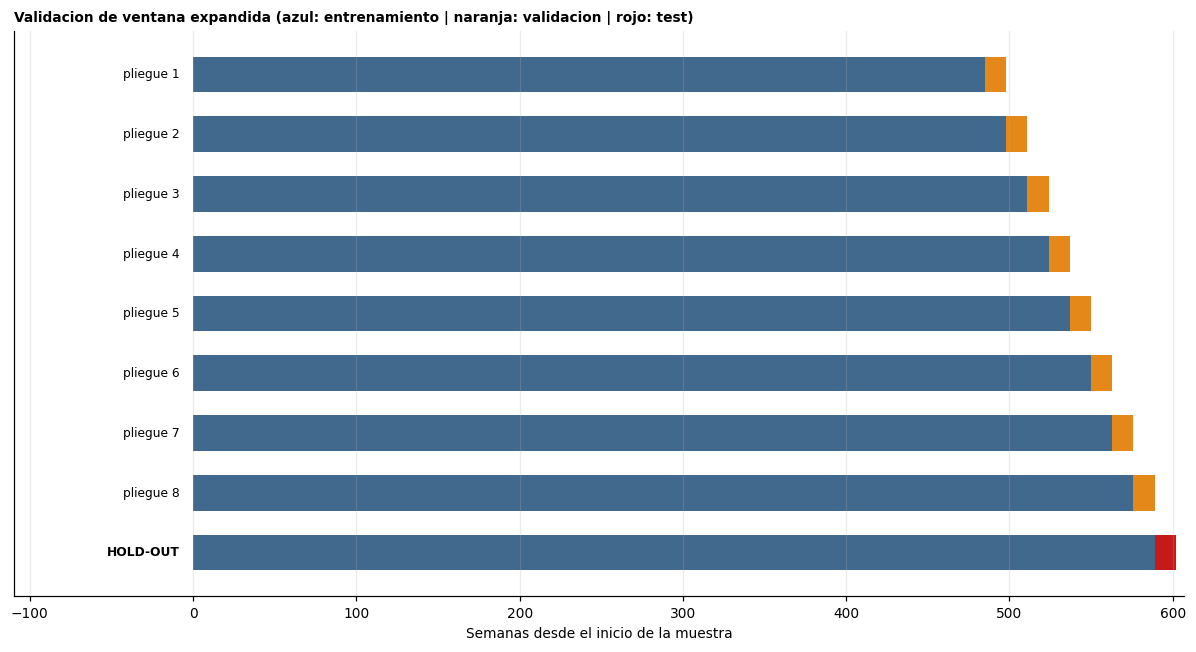

In [ ]:
fig, ax = plt.subplots(figsize=(11, 0.5 * (len(PLIEGUES) + 1) + 1))
for i, (tipo, j, o) in enumerate(PLIEGUES):
    yp = len(PLIEGUES) - i
    ax.barh(yp, o, left=0, height=.6, color=AZUL, alpha=.85)
    ax.barh(yp, H, left=o, height=.6,
            color=ROJO if tipo == "test" else "#e07b00", alpha=.9)
    ax.text(-8, yp, "HOLD-OUT" if tipo == "test" else f"pliegue {j+1}",
            ha="right", va="center", fontsize=8,
            fontweight="bold" if tipo == "test" else "normal")
ax.set_yticks([]); ax.set_xlim(-110, N + 5)
ax.set_xlabel("Semanas desde el inicio de la muestra")
ax.set_title("Validacion de ventana expandida (azul: entrenamiento | naranja: validacion | "
             "rojo: test)", loc="left", fontweight="bold", fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIGS}/fig02_esquema_validacion.png", bbox_inches="tight")
plt.show()

## 4. Motor de ajuste
### 4.1 Caché y ejecución tolerante a fallos

Cada terna `(serie, modelo, pliegue)` produce un vector de 13 pronósticos que se guarda en disco. Tres consecuencias prácticas: una interrupción de Colab no obliga a recomenzar; el bloque deAutoGluon puede correrse en otra sesión sin perder nada; y la evaluación es reproducible sin volver a entrenar. Las excepciones se capturan y se registran, de modo que la falla de un modelo —una versión de librería, una arquitectura que no converge— no interrumpe la corrida.

In [ ]:
RUTA_CACHE = f"{OUT}/predicciones_v2.pkl"
RUTA_FAM   = f"{OUT}/familias_v2.json"

PRED = pickle.load(open(RUTA_CACHE, "rb")) if os.path.exists(RUTA_CACHE) else {}
# nombre de modelo -> familia. Se persiste para que la evaluacion funcione en una
# sesion nueva que solo lea la cache (por ejemplo, tras correr AutoGluon aparte).
FAMILIA = json.load(open(RUTA_FAM)) if os.path.exists(RUTA_FAM) else {}
ERRORES = []

def guardar_cache():
    with open(RUTA_CACHE, "wb") as f:
        pickle.dump(PRED, f)
    with open(RUTA_FAM, "w") as f:
        json.dump(FAMILIA, f, indent=1)

def _limpiar():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def correr(nombre, fn, fam="", forzar=False):
    '''fn(sid, origen) -> array de H pronosticos. Recorre las 3 series y los pliegues.'''
    FAMILIA[nombre] = fam
    t0, n_err = time.time(), 0
    for sid in SERIES:
        for tipo, j, o in PLIEGUES:
            clave = (sid, nombre, tipo, j)
            if clave in PRED and not forzar:
                continue
            try:
                PRED[clave] = np.asarray(fn(sid, o), dtype=float)
            except Exception as e:
                ERRORES.append((sid, nombre, tipo, j, repr(e)[:180])); n_err += 1
                PRED[clave] = np.full(H, np.nan)
            _limpiar()
    guardar_cache()
    print(f"  {nombre:22s} {time.time()-t0:7.1f} s" + (f"  [{n_err} errores]" if n_err else ""))

def correr_multi(nombre, fn, fam="", forzar=False):
    '''fn(origen) -> dict sid -> array de H. Para modelos que pronostican las 3 a la vez.'''
    FAMILIA[nombre] = fam
    t0, n_err = time.time(), 0
    for tipo, j, o in PLIEGUES:
        if all((sid, nombre, tipo, j) in PRED for sid in SERIES) and not forzar:
            continue
        try:
            d = fn(o)
            for sid in SERIES:
                PRED[(sid, nombre, tipo, j)] = np.asarray(d[sid], dtype=float)
        except Exception as e:
            ERRORES.append(("*", nombre, tipo, j, repr(e)[:180])); n_err += 1
            for sid in SERIES:
                PRED[(sid, nombre, tipo, j)] = np.full(H, np.nan)
        _limpiar()
    guardar_cache()
    print(f"  {nombre:22s} {time.time()-t0:7.1f} s" + (f"  [{n_err} errores]" if n_err else ""))

print(f"Cache: {len(PRED)} pronosticos ya calculados")

Cache: 837 pronosticos ya calculados


### 4.2 Ajuste genérico de los modelos de Darts

Los cuatro puntos donde podría filtrarse información del futuro se controlan explícitamente:
1. **Truncamiento del objetivo** en el origen del pliegue.
2. **Truncamiento de las covariables pasadas** en el mismo punto. Con   `output_chunk_length = H` Darts no las usaría más allá del origen, pero truncarlas convierte la garantía en estructural y no dependiente de la versión de la librería.
3. **Escaladores ajustados solo con el tramo de entrenamiento.** Ajustar un `MinMaxScaler` sobre la muestra completa es la fuga silenciosa más frecuente en este tipo de trabajos: el máximo de la serie es información del futuro.
4. **Filtro de indicadoras** sin variación en el tramo de entrenamiento.

In [ ]:
def exog_futuras(sid, fin_train):
    '''Calendario + indicadoras identificables en el tramo de entrenamiento.'''
    dum = dummies_interv(idx_ext, sid)
    if dum.shape[1]:
        keep = [c for c in dum.columns if dum[c].iloc[:fin_train].std(ddof=0) > 0]
        dum = dum[keep]
    return CAL_TS if dum.shape[1] == 0 else CAL_TS.stack(a_ts(dum))


def ajustar_darts(spec, y_full, pc_full, fc_full, fin_train, h=H):
    '''Nucleo comun: trunca, escala con el tramo de entrenamiento, ajusta y predice.'''
    ytr  = y_full[:fin_train]
    if spec.get("f64"):
        # La familia Theta opera internamente en doble precision; con float32
        # falla al dividir la serie por su factor estacional.
        ytr = ytr.astype(np.float64)
    pctr = pc_full[:fin_train] if (spec["pc"] and pc_full is not None) else None
    fc   = fc_full if (spec["fc"] and fc_full is not None) else None

    if spec["esc"]:
        sc_y = Scaler(); ytr_m = sc_y.fit_transform(ytr)
        pctr_m = Scaler().fit_transform(pctr) if pctr is not None else None
        if fc is not None:
            sc_f = Scaler(); sc_f.fit(fc[:fin_train]); fc_m = sc_f.transform(fc)
        else:
            fc_m = None
    else:
        sc_y, ytr_m, pctr_m, fc_m = None, ytr, pctr, fc

    modelo = spec["fab"]()
    kw = {}
    if pctr_m is not None:
        kw["past_covariates"] = pctr_m
    if fc_m is not None:
        kw["future_covariates"] = fc_m
    modelo.fit(ytr_m, **kw)
    pred = modelo.predict(n=h, **kw)
    return sc_y.inverse_transform(pred) if sc_y is not None else pred


def predecir_uni(nombre, sid, fin_train, h=H):
    '''Modelo por serie: devuelve un array de h valores en logaritmos.'''
    spec = ESPECIFICACIONES[nombre]
    p = ajustar_darts(spec, TS[sid]["y"], TS[sid]["pc"],
                      exog_futuras(sid, fin_train), fin_train, h)
    return p.values().ravel()

### 4.3 Registro de modelos y justificación de los hiperparámetros

Cada modelo se declara como una **fábrica** —una función sin argumentos que devuelve una instancia nueva— porque cada pliegue exige un objeto virgen: reutilizar uno ya ajustado arrastraría pesos entrenados con datos posteriores.
| Modelo | Configuración | Razón |
|---|---|---|
| `Naive` | último valor | Cota inferior. En el TP1 el paseo aleatorio resultó imbatible en el precio. |
| `SeasonalNaive` | rezago 52 | Referencia exigente bajo estacionalidad marcada; es el denominador del MASE. |
| `NaiveDrift` | recta entre extremos | Controla si lo único presente es deriva. |
| `Theta` | descomposición de Assimakopoulos-Nikolopoulos, estacionalidad multiplicativa | Ganador de la competencia M3; benchmark estadístico obligado. |
| `HoltWinters` | ETS aditivo con `seasonal_periods = 52` | El informe de referencia de la cátedra lo encontró competitivo pese a su simplicidad. |
| `LightGBM` / `XGBoost` / `CatBoost` | mismos rezagos, `lr = 0.05`, 400 árboles, profundidad moderada | Rezagos idénticos entre los tres para que la comparación aísle el algoritmo y no la representación. Con ~500 observaciones efectivas, árboles más grandes sobreajustan de inmediato. `multi_models=True` ajusta un modelo por paso del horizonte (estrategia directa). |
| `N-BEATS` | genérico, 2 stacks × 3 bloques, capas de 256 | Cercano al artículo original, reducido por el tamaño muestral. No admite covariables futuras. |
| `N-HiTS` | 3 stacks con interpolación jerárquica | Su multirresolución está diseñada para horizontes largos como 13 pasos. |
| `TSMixer` | `hidden = 64`, 4 bloques | Mezcla temporal y de canales; admite ambos tipos de covariables.
| `TiDE` | codificador/decodificador de 2 capas, `hidden = 128` | Alternativa densa eficiente, con buen desempeño documentado con covariables futuras. |
| `LSTM` | `BlockRNN`, 2 capas de 64, dropout 0,1 | Recurrente clásico; el bloque de 13 pasos se emite de una vez, no recursivamente. |
| `DLinear` | descomposición tendencia/estacional + lineal | Zeng et al. (2023) mostraron que una lineal bien planteada supera a muchos transformers. Es el control de complejidad del bloque. |
| `Prophet` | estacionalidad anual, `changepoint_prior_scale = 0.05` | Aditivo interpretable, con el calendario como regresores. |

Las redes se entrenan con `EPOCAS` fijas en lugar de parada temprana: esta última exigiría reservarun tramo de validación **dentro** de cada pliegue, lo que reduciría el entrenamiento efectivo yharía que el número de observaciones difiriera entre pliegues, contaminando la comparación.

In [ ]:
KW_TORCH = dict(
    input_chunk_length=ICL, output_chunk_length=H,
    n_epochs=EPOCAS, batch_size=32, random_state=SEED,
    optimizer_kwargs={"lr": 1e-3},
    pl_trainer_kwargs={"accelerator": "auto", "enable_progress_bar": False,
                       "logger": False, "enable_model_summary": False,
                       "enable_checkpointing": False},
)

# Rezagos comunes a los modelos de regresion: estructura corta (1-8), trimestral
# (13, 26) y anual (52). Deliberadamente identicos en los tres algoritmos.
LAGS_Y  = [-1, -2, -3, -4, -5, -6, -7, -8, -13, -26, -52]
LAGS_PC = [-1, -2, -4, -13, -52]

ESPECIFICACIONES = {
    # ---- A. Benchmarks -----------------------------------------------------
    "Naive":         dict(fab=lambda: NaiveSeasonal(K=1),  esc=False, pc=False, fc=False),
    "SeasonalNaive": dict(fab=lambda: NaiveSeasonal(K=M),  esc=False, pc=False, fc=False),
    "NaiveDrift":    dict(fab=lambda: NaiveDrift(),        esc=False, pc=False, fc=False),
    "Theta":         dict(fab=lambda: Theta(season_mode=SeasonalityMode.MULTIPLICATIVE,
                                            seasonality_period=M),
                          esc=False, pc=False, fc=False, f64=True),
    "FourTheta":     dict(fab=lambda: FourTheta(season_mode=SeasonalityMode.MULTIPLICATIVE,
                                                seasonality_period=M),
                          esc=False, pc=False, fc=False, f64=True),
    "HoltWinters":   dict(fab=lambda: ExponentialSmoothing(seasonal_periods=M),
                          esc=False, pc=False, fc=False, f64=True),

    # ---- D. ML tabular univariado ------------------------------------------
    "LightGBM": dict(esc=False, pc=True, fc=True,
                     fab=lambda: LightGBMModel(
                         lags=LAGS_Y, lags_past_covariates=LAGS_PC,
                         lags_future_covariates=[0], output_chunk_length=H,
                         multi_models=True, random_state=SEED,
                         n_estimators=400, learning_rate=0.05, num_leaves=31,
                         min_child_samples=20, subsample=0.9, subsample_freq=1,
                         colsample_bytree=0.8, verbose=-1)),
    "XGBoost":  dict(esc=False, pc=True, fc=True,
                     fab=lambda: XGBModel(
                         lags=LAGS_Y, lags_past_covariates=LAGS_PC,
                         lags_future_covariates=[0], output_chunk_length=H,
                         multi_models=True, random_state=SEED,
                         n_estimators=400, learning_rate=0.05, max_depth=5,
                         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                         verbosity=0)),
    "CatBoost": dict(esc=False, pc=True, fc=True,
                     fab=lambda: CatBoostModel(
                         lags=LAGS_Y, lags_past_covariates=LAGS_PC,
                         lags_future_covariates=[0], output_chunk_length=H,
                         multi_models=True, random_state=SEED,
                         iterations=400, learning_rate=0.05, depth=6, verbose=0)),

    # ---- F. Deep learning univariado ---------------------------------------
    "N-BEATS": dict(esc=True, pc=True, fc=False,
                    fab=lambda: NBEATSModel(generic_architecture=True, num_stacks=2,
                                            num_blocks=3, num_layers=4, layer_widths=256,
                                            dropout=0.1, **KW_TORCH)),
    "N-HiTS":  dict(esc=True, pc=True, fc=False,
                    fab=lambda: NHiTSModel(num_stacks=3, num_blocks=1, num_layers=2,
                                           layer_widths=256, dropout=0.1, **KW_TORCH)),
    "TSMixer": dict(esc=True, pc=True, fc=True,
                    fab=lambda: TSMixerModel(hidden_size=64, ff_size=64, num_blocks=4,
                                             dropout=0.1, **KW_TORCH)),
    "TiDE":    dict(esc=True, pc=True, fc=True,
                    fab=lambda: TiDEModel(num_encoder_layers=2, num_decoder_layers=2,
                                          decoder_output_dim=16, hidden_size=128,
                                          temporal_decoder_hidden=32, dropout=0.1,
                                          use_layer_norm=True, **KW_TORCH)),
    "LSTM":    dict(esc=True, pc=True, fc=False,
                    fab=lambda: BlockRNNModel(model="LSTM", hidden_dim=64, n_rnn_layers=2,
                                              dropout=0.1, **KW_TORCH)),
    "DLinear": dict(esc=True, pc=True, fc=True,
                    fab=lambda: DLinearModel(kernel_size=25, **KW_TORCH)),

    # ---- G. Hibrido aditivo -------------------------------------------------
    "Prophet": dict(esc=False, pc=False, fc=True,
                    fab=lambda: Prophet(yearly_seasonality=True, weekly_seasonality=False,
                                        daily_seasonality=False, seasonality_mode="additive",
                                        changepoint_prior_scale=0.05)),
}
print(f"{len(ESPECIFICACIONES)} modelos declarados en el registro de Darts")

16 modelos declarados en el registro de Darts


---
## 5. Modelos clásicos y multivariados fuera de Darts
### 5.1 ARIMA + Fourier y SARIMA del TP1

Se implementan con `statsmodels` para reproducir **exactamente** las especificaciones del TP1. Conviene precisar el estatus de cada una. La regresión armónica dinámica —ARIMA con armónicos de Fourier como regresores exógenos— obtuvo en el TP1 el menor AIC en las tres series y el menor RMSE bajo ventana fija. Aun así, el modelo **adoptado** allí fue el SARIMA: evaluado en origen móvil de un paso —esquema en el que la variante de Fourier no se evaluó— el SARIMA logró el menor error detoda la comparación. Aquí se incluyen ambos, sobre el mismo hold-out que el resto.

In [ ]:
# Especificaciones SARIMA adoptadas en el TP1.
#   S1: criterio BIC (dAIC = 1,08 frente al de menor AIC -> regla de parsimonia)
#   S2: criterio AIC (dAIC = 7,85)
#   S3: BIC / parsimonia; el de menor AIC, (3,1,3)(1,0,0)52, resulto sobreajuste
ORDENES_TP1 = {
    "S1": dict(order=(2, 0, 0), seasonal_order=(1, 0, 0, M)),
    "S2": dict(order=(2, 0, 1), seasonal_order=(0, 0, 1, M)),
    "S3": dict(order=(0, 1, 1), seasonal_order=(0, 0, 0, 0)),
}
# Regresion armonica dinamica: ordenes y armonicos seleccionados en el TP1 por el
# barrido sobre K in {1,2,3,4}. No coinciden con los del SARIMA adoptado.
ORDENES_FOURIER_TP1 = {
    "S1": dict(order=(1, 0, 1), K=4),
    "S2": dict(order=(2, 0, 1), K=4),
    "S3": dict(order=(0, 1, 1), K=4),
}


def fourier_df(idx_sub, K, t0=0):
    t = np.arange(t0, t0 + len(idx_sub))
    d = {}
    for k in range(1, K + 1):
        d[f"sin{k}"] = np.sin(2 * np.pi * k * t / M)
        d[f"cos{k}"] = np.cos(2 * np.pi * k * t / M)
    return pd.DataFrame(d, index=idx_sub)


def _exog_arima(sid, fin_train, h, K=None):
    '''Fourier(K) + indicadoras identificables. Devuelve (X_train, X_futuro).'''
    n_tot = fin_train + h
    bloques = []
    if K:
        bloques.append(fourier_df(idx_ext[:n_tot], K))
    dum = dummies_interv(idx_ext, sid).iloc[:n_tot]
    if dum.shape[1]:
        keep = [c for c in dum.columns if dum[c].iloc[:fin_train].std(ddof=0) > 0]
        if keep:
            bloques.append(dum[keep])
    if not bloques:
        return None, None
    X = pd.concat(bloques, axis=1)
    return X.iloc[:fin_train], X.iloc[fin_train:]


def ajustar_arima(sid, fin_train, h=H, estacional=False, devolver_res=False):
    y = log_panel[f"l{SERIES[sid]['col']}"].iloc[:fin_train]
    if estacional:
        o = ORDENES_TP1[sid]; order, sorder, K = o["order"], o["seasonal_order"], None
    else:
        o = ORDENES_FOURIER_TP1[sid]; order, sorder, K = o["order"], (0, 0, 0, 0), o["K"]
    Xtr, Xf = _exog_arima(sid, fin_train, h, K=K)
    res = SARIMAX(y, order=order, seasonal_order=sorder, exog=Xtr,
                  trend="c" if order[1] == 0 else "n",
                  enforce_stationarity=False,
                  enforce_invertibility=False).fit(disp=False, maxiter=200)
    pred = np.asarray(res.forecast(steps=h, exog=Xf), dtype=float)
    return (pred, res) if devolver_res else pred

### 5.2 VAR y VARX: el sistema completo

Este es el bloque que la comparación exigía y que un conjunto de modelos univariados no puede sustituir. El VAR trata a las tres series como **endógenas**: cada una se explica por los rezagosde todas, incluidas las propias, y el pronóstico se genera resolviendo el sistema hacia adelante.La diferencia con "meter las otras dos series como covariables pasadas" no es de matiz: en el sistema hay **realimentación** —un shock en la comercialización altera el ingreso, que a su vez retroalimenta la comercialización en el período siguiente—, mientras que en el modelo univariado con exógenas las otras series son un insumo dado que nunca responde.

Especificación, heredada del TP1 y obligada por los órdenes de integración que allí se establecieron: el sistema es `(ln S1, ln S2, Δln S3)`. El precio entra en primera diferenciaporque es **I(1)**, mientras que S1 y S2 son **I(0)** con estacionalidad determinística. Incluir una variable I(1) en niveles junto a dos I(0) produciría una regresión espuria; el TP1 verificó además que el test de Johansen rechaza la existencia de cointegración interpretable, de modo que un VECM queda descartado. Como el sistema pronostica `Δln S3`, el nivel de `ln S3` se reconstruye por **suma acumulada** desde la última observación disponible en el origen. Dos variantes:
- **VAR**: solo armónicos de Fourier como determinísticos, con el orden `p` elegido por AIC en  cada pliegue —no fijado de antemano, porque la longitud de la muestra cambia entre pliegues—.
- **VARX**: agrega las indicadoras de intervención identificables como exógenas.

In [ ]:
K_VAR = 2          # pares de armonicos en el sistema (el TP1 uso 2)

def _sistema_var():
    '''Sistema estacionario del TP1: (ln S1, ln S2, D ln S3).'''
    Z = pd.DataFrame({
        "lS1":  log_panel["lcamiones"],
        "lS2":  log_panel["lcomercializacion"],
        "dlS3": log_panel["lprecio"].diff(),
    }).dropna()
    return Z                      # Z.index[k] == log_panel.index[k+1]


Z_VAR = _sistema_var()


def ajustar_predecir_var(fin_train, h=H, con_exog=False, maxlags=8):
    '''Ajusta el VAR con datos hasta fin_train y devuelve dict sid -> array de h (en logs).'''
    # El sistema perdio la primera observacion por la diferencia: alinear el corte
    n_tr = fin_train - 1
    Ztr  = Z_VAR.iloc[:n_tr]

    if con_exog:
        dum_todas = pd.concat([dummies_interv(idx_ext, s) for s in SERIES], axis=1)
        dum_todas = dum_todas.loc[:, ~dum_todas.columns.duplicated()]
        X = pd.concat([fourier_df(idx_ext, K_VAR), dum_todas], axis=1).iloc[1:1 + n_tr + h]
        keep = [c for c in X.columns if X[c].iloc[:n_tr].std(ddof=0) > 0]
        X = X[keep]
    else:
        X = fourier_df(idx_ext, K_VAR).iloc[1:1 + n_tr + h]

    Xtr, Xf = X.iloc[:n_tr].values, X.iloc[n_tr:n_tr + h].values

    res = VAR(Ztr.values, exog=Xtr).fit(maxlags=maxlags, ic="aic")
    if res.k_ar == 0:                     # el AIC puede elegir p = 0; forzar p = 1
        res = VAR(Ztr.values, exog=Xtr).fit(1)
    p = res.k_ar
    fc = res.forecast(y=Ztr.values[-p:], steps=h, exog_future=Xf)

    # Reconstruccion del nivel del precio desde la diferencia pronosticada
    ult_lS3 = log_panel["lprecio"].iloc[fin_train - 1]
    return {"S1": fc[:, 0],
            "S2": fc[:, 1],
            "S3": ult_lS3 + np.cumsum(fc[:, 2])}

### 5.3 ML multivariado: `ForecasterDirectMultiVariate`

El análogo no lineal del VAR, con la librería `skforecast` vista en la Clase 5. La lógica es la misma —los rezagos de las tres series predicen cada una— pero la función que los combina es unLightGBM en lugar de una ecuación lineal. La estrategia es **directa**: se entrena un modelo distinto para cada uno de los 13 pasos del horizonte, en lugar de realimentar el pronóstico. Con horizontes largos la estrategia directa evita la acumulación de error de la recursiva, al costo de estimar trece modelos por serie. Lo que este modelo captura y el VAR no: interacciones no lineales y efectos umbral. Que la comercialización anticipe el ingreso es plausible que dependa del nivel —una venta de tres millones de toneladas no se traduce en camiones de manera proporcional a una de trescientas mil,porque la capacidad de recepción satura—.
Un VAR impone linealidad; un árbol no.

In [ ]:
import inspect as _inspect
try:                                            # skforecast >= 0.14
    from skforecast.direct import ForecasterDirectMultiVariate
except ImportError:                             # versiones anteriores
    from skforecast.ForecasterAutoregMultiVariate import (
        ForecasterAutoregMultiVariate as ForecasterDirectMultiVariate)
from lightgbm import LGBMRegressor

# La API cambio de nombre entre versiones: 'regressor' hasta 0.16, 'estimator' desde
# 0.17. Se detecta en tiempo de ejecucion para no depender de la version instalada.
_ARG_REG = ("estimator"
            if "estimator" in _inspect.signature(
                ForecasterDirectMultiVariate.__init__).parameters
            else "regressor")

LAGS_SKF = [1, 2, 3, 4, 5, 6, 7, 8, 13, 26, 52]


def _a_vector(p):
    '''predict() devuelve DataFrame (level, pred) en versiones nuevas y Series en viejas.'''
    if isinstance(p, pd.DataFrame):
        col = "pred" if "pred" in p.columns else p.columns[-1]
        return p[col].to_numpy(dtype=float)
    return np.asarray(p, dtype=float).ravel()


def ajustar_predecir_skf(sid, fin_train, h=H):
    '''LightGBM multivariado directo: los rezagos de las 3 series predicen la serie sid.'''
    nivel = f"l{SERIES[sid]['col']}"
    # skforecast exige que el indice declare su frecuencia
    series_tr = log_panel.iloc[:fin_train].asfreq(FREQ)
    exog = calendario.iloc[:fin_train + h].asfreq(FREQ)

    reg = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                        min_child_samples=20, subsample=0.9, subsample_freq=1,
                        colsample_bytree=0.8, random_state=SEED, verbose=-1)
    f = ForecasterDirectMultiVariate(**{_ARG_REG: reg},
                                     level=nivel, lags=LAGS_SKF, steps=h)
    f.fit(series=series_tr, exog=exog.iloc[:fin_train])
    return _a_vector(f.predict(steps=h, exog=exog.iloc[fin_train:fin_train + h]))

### 5.4 Deep learning multivariado y global

Dos formas distintas de que una sola red sirva a las tres series, que conviene no confundir:
- **Multivariado (`-MV`)**: el objetivo es una serie de **tres componentes**. La red ve las tres  trayectorias simultáneamente y aprende sus interacciones —el *channel mixing* de TSMixer es  literalmente eso—. Es el análogo neuronal del VAR.
- **Global (`-Global`)**: un único conjunto de parámetros entrenado sobre las tres series tratadas  como **realizaciones independientes** del mismo proceso. No hay interacción entre ellas, pero el  modelo dispone del triple de observaciones para estimar los mismos pesos. Es el paradigma que  llevado al extremo —millones de series— produce los modelos fundacionales de la sección 7.Con 602 observaciones por serie, la escasez muestral es la restricción dominante, de modo queambas variantes tienen fundamento a priori y la comparación empírica decide.

In [ ]:
def ajustar_predecir_mv(nombre_base, fin_train, h=H):
    '''Red con objetivo de 3 componentes. Devuelve dict sid -> array de h.'''
    fabricas = {
        "TSMixer-MV": lambda: TSMixerModel(hidden_size=64, ff_size=64, num_blocks=4,
                                           dropout=0.1, **KW_TORCH),
        "TiDE-MV":    lambda: TiDEModel(num_encoder_layers=2, num_decoder_layers=2,
                                        decoder_output_dim=16, hidden_size=128,
                                        temporal_decoder_hidden=32, dropout=0.1,
                                        use_layer_norm=True, **KW_TORCH),
    }
    ytr = Y_MV[:fin_train]
    sc_y = Scaler(); ytr_m = sc_y.fit_transform(ytr)
    fc = CAL_TS
    sc_f = Scaler(); sc_f.fit(fc[:fin_train]); fc_m = sc_f.transform(fc)

    m = fabricas[nombre_base]()
    m.fit(ytr_m, future_covariates=fc_m)
    pred = sc_y.inverse_transform(m.predict(n=h, future_covariates=fc_m))
    vals = pred.values()                      # (h, 3) en el orden de log_panel
    return {SID_DE_COL[c]: vals[:, k] for k, c in enumerate(COLS)}


def ajustar_predecir_global(fin_train, h=H):
    '''N-HiTS entrenado sobre las 3 series como panel. Devuelve dict sid -> array.'''
    ys  = [TS[sid]["y"][:fin_train] for sid in SERIES]
    pcs = [TS[sid]["pc"][:fin_train] for sid in SERIES]
    sc_y = Scaler(); ys_m = sc_y.fit_transform(ys)      # un escalador por serie
    pcs_m = Scaler().fit_transform(pcs)

    m = NHiTSModel(num_stacks=3, num_blocks=1, num_layers=2, layer_widths=256,
                   dropout=0.1, **KW_TORCH)
    m.fit(ys_m, past_covariates=pcs_m)
    preds = sc_y.inverse_transform(m.predict(n=h, series=ys_m, past_covariates=pcs_m))
    return {sid: preds[k].values().ravel() for k, sid in enumerate(SERIES)}

### 5.5 Híbrido: ARIMA + Fourier con corrección no lineal de residuos

El esquema de Zhang (2003): un modelo lineal captura la estructura que sabe capturar y un modelo no lineal aprende lo que quedó en el residuo.$$y_t = L_t + N_t, \qquad \hat{y}_t = \underbrace{\text{ARIMA-Fourier}(y)}_{\hat{L}_t} + \underbrace{\text{LightGBM}(e_{t-1}, e_{t-2}, \dots)}_{\hat{N}_t}$$

La justificación teórica es directa: si los residuos del modelo lineal fueran ruido blanco, el LightGBM no encontraría nada y el híbrido colapsaría al lineal —lo que en sí mismo es información útil—. Pero el TP1 documentó que los residuos del SARIMA **rechazan la homocedasticidad**(ARCH-LM en las tres series) y muestran curtosis elevada, señales de estructura de segundo ordenque la clase ARIMA no describe.

El híbrido pone a prueba si esa estructura es aprovechable para elpronóstico de la media.El LightGBM se entrena únicamente sobre los residuos **dentro de muestra** del tramo de entrenamiento, con el calendario como covariable futura, y su pronóstico se suma al del ARIMA.

In [ ]:
def ajustar_predecir_hibrido(sid, fin_train, h=H):
    '''ARIMA + Fourier y LightGBM sobre sus residuos dentro de muestra.'''
    pred_lin, res = ajustar_arima(sid, fin_train, h, estacional=False, devolver_res=True)

    resid = pd.Series(np.asarray(res.resid, dtype=float),
                      index=log_panel.index[:fin_train]).iloc[M:]     # descarta el burn-in
    ts_res = a_ts(resid)

    fc = CAL_TS
    m = LightGBMModel(lags=[-1, -2, -3, -4, -8, -13, -26, -52],
                      lags_future_covariates=[0], output_chunk_length=h,
                      multi_models=True, random_state=SEED,
                      n_estimators=250, learning_rate=0.05, num_leaves=15,
                      min_child_samples=20, verbose=-1)
    m.fit(ts_res, future_covariates=fc)
    pred_nolin = m.predict(n=h, future_covariates=fc).values().ravel()
    return pred_lin + pred_nolin

---
## 6. Ejecución de los bloques A a G

Orden deliberado: primero lo barato, para tener resultados utilizables desde temprano, y al final el bloque de deep learning, que concentra el costo. Todo queda cacheado.

### 6.1 Benchmarks y clásicos

In [ ]:
print("A. Benchmarks ingenuos y estadisticos:")
for n in ["Naive", "SeasonalNaive", "NaiveDrift", "Theta", "FourTheta", "HoltWinters"]:
    correr(n, lambda sid, o, nm=n: predecir_uni(nm, sid, o), fam="Baseline")

print("\nB. Clasicos del TP1:")
correr("ARIMA-Fourier", lambda sid, o: ajustar_arima(sid, o, estacional=False),
       fam="Clasico")
if CORRER_SARIMA:
    correr("SARIMA-TP1", lambda sid, o: ajustar_arima(sid, o, estacional=True),
           fam="Clasico")

A. Benchmarks ingenuos y estadisticos:
  Naive                      0.0 s
  SeasonalNaive              0.0 s
  NaiveDrift                 0.0 s
  Theta                      0.0 s
  FourTheta                  0.0 s
  HoltWinters                0.0 s

B. Clasicos del TP1:
  ARIMA-Fourier              0.0 s
  SARIMA-TP1                 0.0 s


### 6.2 Multivariado clásico y de machine learning

In [ ]:
print("C. Multivariado clasico:")
correr_multi("VAR",  lambda o: ajustar_predecir_var(o, con_exog=False), fam="Multivariado")
correr_multi("VARX", lambda o: ajustar_predecir_var(o, con_exog=True),  fam="Multivariado")

print("\nE. ML multivariado:")
correr("SKF-MultiVar", ajustar_predecir_skf, fam="Multivariado")

C. Multivariado clasico:
  VAR                        0.0 s
  VARX                       0.0 s

E. ML multivariado:
  SKF-MultiVar               0.0 s


### 6.3 Machine learning tabular e híbridos

In [ ]:
print("D. ML tabular univariado:")
for n in ["LightGBM", "XGBoost", "CatBoost"]:
    correr(n, lambda sid, o, nm=n: predecir_uni(nm, sid, o), fam="ML")

print("\nG. Hibridos:")
correr("Prophet", lambda sid, o: predecir_uni("Prophet", sid, o), fam="Hibrido")
correr("ARIMA+LGBM", ajustar_predecir_hibrido, fam="Hibrido")

D. ML tabular univariado:
  LightGBM                   0.0 s
  XGBoost                    0.0 s
  CatBoost                   0.0 s

G. Hibridos:
  Prophet                    0.0 s
  ARIMA+LGBM                 0.0 s


### 6.4 Deep learnin

El bloque más costoso: seis arquitecturas × tres series × nueve ajustes = 162 entrenamientos.

Con GPU, del orden de 60 a 100 minutos.

In [ ]:
print("F. Deep learning univariado:")
for n in ["DLinear", "N-HiTS", "N-BEATS", "TSMixer", "TiDE", "LSTM"]:
    correr(n, lambda sid, o, nm=n: predecir_uni(nm, sid, o), fam="DL")

F. Deep learning univariado:
  DLinear                    0.0 s
  N-HiTS                     0.0 s
  N-BEATS                    0.0 s
  TSMixer                    0.0 s
  TiDE                       0.0 s
  LSTM                       0.0 s


In [ ]:
print("F'. Deep learning multivariado y global:")
correr_multi("TSMixer-MV", lambda o: ajustar_predecir_mv("TSMixer-MV", o), fam="DL-MV")
correr_multi("TiDE-MV",    lambda o: ajustar_predecir_mv("TiDE-MV", o),    fam="DL-MV")
correr_multi("NHiTS-Global", ajustar_predecir_global, fam="DL-Global")

if ERRORES:
    print("\nErrores registrados hasta aqui:")
    for e in ERRORES[:25]:
        print("  ", e)

F'. Deep learning multivariado y global:
  TSMixer-MV                 0.0 s
  TiDE-MV                    0.0 s
  NHiTS-Global               0.0 s


---
## 7. Modelos fundacionales: Chronos

**Chronos** (Ansari, Stella et al., 2024, Amazon Science) trata una serie temporal como un **lenguaje**. El procedimiento tiene tres pasos: se escala la serie, se **cuantiza** en 4.096 tokens discretos, y se entrena una arquitectura T5 —la misma de los modelos de lenguaje— para predecir el próximo token con pérdida de entropía cruzada. El pronóstico se obtiene muestreando múltiples trayectorias futuras condicionadas al contexto histórico, lo que lo hace **probabilístico** por construcción. Lo relevante para este trabajo es que Chronos se usa **zero-shot**: el modelo fue entrenado sobre un corpus enorme de series públicas y sintéticas generadas por procesos gaussianos, y **nunca vio estos datos**. No hay ajuste, no hay hiperparámetros que elegir, no hay riesgo de sobreajuste a la muestra. Recibe el contexto y devuelve el pronóstico.Esto plantea la pregunta más interesante de la comparación: ¿puede un modelo que no sabe nada del complejo sojero argentino competir con uno estimado específicamente sobre estas series? La respuesta tiene consecuencias prácticas inmediatas para un área de análisis económico. **Dos variantes:**
- **Chronos-T5** (`base`, 200 M de parámetros): el modelo original, con muestreo de trayectorias.
- **Chronos-Bolt** (`base`): una revisión posterior que procesa parches de la serie en un esquema  encoder-decoder y predice cuantiles directamente. Es del orden de 250 veces más rápido y  típicamente más preciso.

**Advertencias metodológicas.** Primera: Chronos es **estrictamente univariado** y no admite covariables, de modo que no puede aprovechar la información cruzada que el VAR sí explota; la comparación con los modelos multivariados es informativa justamente por eso. Segunda: el contextose limita a las últimas 512 observaciones, que aquí cubren casi diez años. Tercera: se toma la **mediana** de la distribución predictiva como pronóstico puntual, que es el estimador óptimo bajo pérdida absoluta; para el RMSE lo óptimo sería la media, de modo que la comparación es ligeramente conservadora contra Chronos.

In [ ]:
from chronos import BaseChronosPipeline

_PIPES = {}

def pipeline_chronos(nombre_modelo):
    '''Carga perezosa y cacheada: el modelo se descarga una sola vez por sesion.'''
    if nombre_modelo not in _PIPES:
        usa_gpu = torch.cuda.is_available()
        _PIPES[nombre_modelo] = BaseChronosPipeline.from_pretrained(
            nombre_modelo,
            device_map="cuda" if usa_gpu else "cpu",
            torch_dtype=torch.bfloat16 if usa_gpu else torch.float32,
        )
        print(f"    [cargado] {nombre_modelo} en {'GPU' if usa_gpu else 'CPU'}")
    return _PIPES[nombre_modelo]


CONTEXTO_MAX = 512          # ventana de contexto de los modelos Chronos-T5

def predecir_chronos(nombre_modelo, sid, fin_train, h=H):
    '''Pronostico zero-shot. Devuelve la mediana de la distribucion predictiva.'''
    pipe = pipeline_chronos(nombre_modelo)
    ctx = log_panel[f"l{SERIES[sid]['col']}"].iloc[:fin_train].to_numpy()[-CONTEXTO_MAX:]
    q, _ = pipe.predict_quantiles(
        torch.tensor(ctx, dtype=torch.float32),
        prediction_length=h,
        quantile_levels=[0.1, 0.5, 0.9],
    )
    return q[0, :, 1].float().numpy()          # cuantil 0,5 = mediana


print("H. Modelos fundacionales (zero-shot):")
correr("Chronos-T5",   lambda sid, o: predecir_chronos(CHRONOS_MODELO, sid, o),
       fam="Fundacional", forzar=True)
correr("Chronos-Bolt", lambda sid, o: predecir_chronos(BOLT_MODELO, sid, o),
       fam="Fundacional", forzar=True)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-t5-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-t5-base/ad294eaacead15db499b740ea4122266dd2a81a2/config.json "HTTP/1.1 200 OK"


H. Modelos fundacionales (zero-shot):


INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-t5-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-t5-base/ad294eaacead15db499b740ea4122266dd2a81a2/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-t5-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-t5-base/ad294eaacead15db499b740ea4122266dd2a81a2/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-t5-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-t5-base/ad294eaacead15db499b740ea4122266dd2a81a2/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-t5-base/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-t5-base/ad294eaacead15db499b740ea4122266dd2a81a2/generation_config.json "HTTP/1.1 200 OK"


...

INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-bolt-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-bolt-base/5d9f166d69f47aef3401367a7b842e78fe97b121/config.json "HTTP/1.1 200 OK"


  Chronos-T5                48.5 s


INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-bolt-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-bolt-base/5d9f166d69f47aef3401367a7b842e78fe97b121/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-bolt-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-bolt-base/5d9f166d69f47aef3401367a7b842e78fe97b121/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos-bolt-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/amazon/chronos-bolt-base/5d9f166d69f47aef3401367a7b842e78fe97b121/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/amazon/chronos

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

    [cargado] amazon/chronos-bolt-base en GPU
  Chronos-Bolt              22.4 s


### 7.1 Bandas predictivas de Chronos sobre el hold-out

Chronos entrega la distribución completa, no solo un punto. Vale la pena mirarla: la amplitud de las bandas es en sí misma un diagnóstico de cuánta señal encuentra el modelo en cada serie.

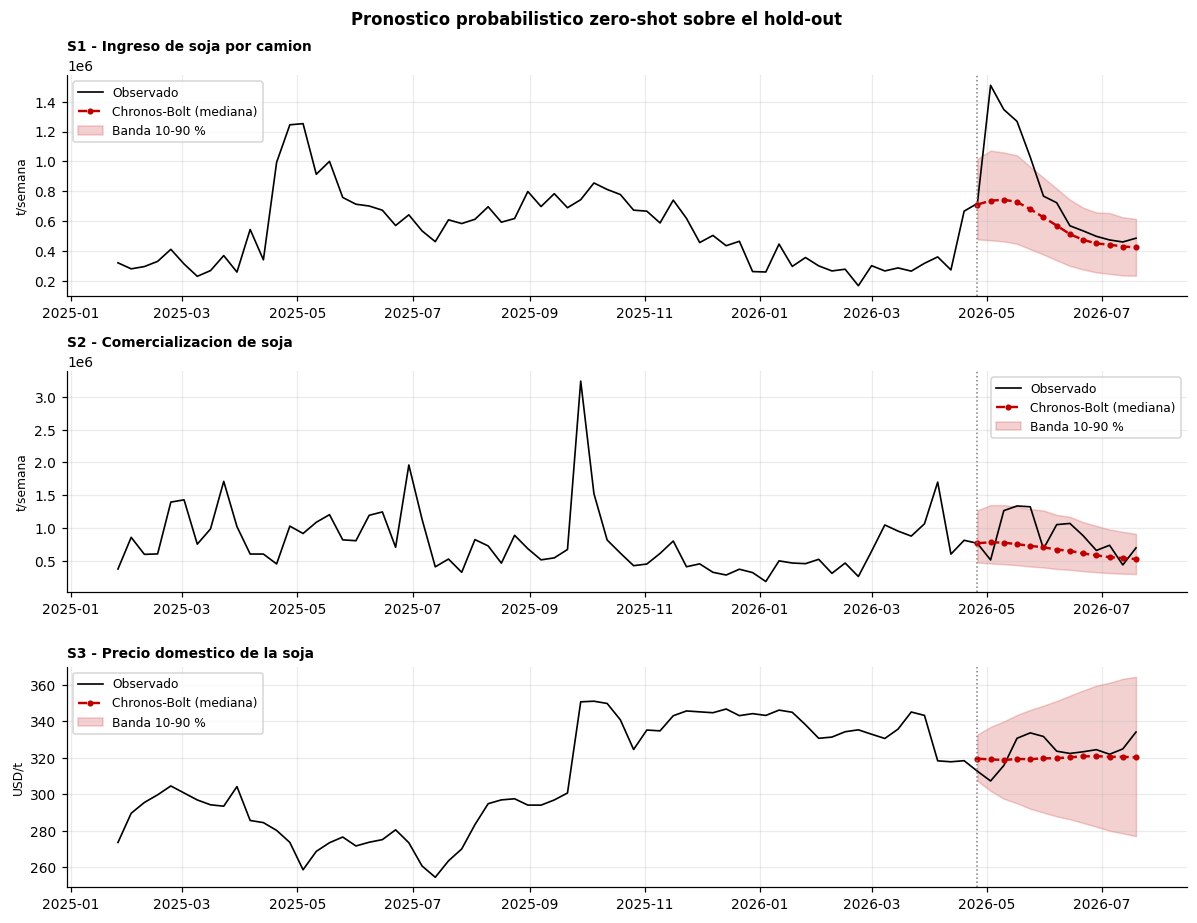

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8.5))
for ax, (sid, cfg) in zip(axes, SERIES.items()):
    pipe = pipeline_chronos(BOLT_MODELO)
    ctx = log_panel[f"l{cfg['col']}"].iloc[:FIN_TRAIN].to_numpy()[-CONTEXTO_MAX:]
    q, _ = pipe.predict_quantiles(torch.tensor(ctx, dtype=torch.float32),
                                  prediction_length=H, quantile_levels=[0.1, 0.5, 0.9])
    lo, med, hi = [np.exp(q[0, :, k].float().numpy()) for k in range(3)]

    hist = np.exp(log_panel[f"l{cfg['col']}"].iloc[-78:])
    ax.plot(hist.index, hist.values, color="black", lw=1.1, label="Observado")
    ax.plot(idx[FIN_TRAIN:], med, color=ROJO, lw=1.6, ls="--", marker="o", ms=3,
            label="Chronos-Bolt (mediana)")
    ax.fill_between(idx[FIN_TRAIN:], lo, hi, color=ROJO, alpha=.18, label="Banda 10-90 %")
    ax.axvline(idx[FIN_TRAIN], color=GRIS, ls=":", lw=1)
    ax.set_ylabel(cfg["unidad"], fontsize=8); ax.legend(fontsize=8)
    ax.set_title(cfg["etiq"], loc="left", fontweight="bold", fontsize=9)
fig.suptitle("Pronostico probabilistico zero-shot sobre el hold-out", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIGS}/fig03_chronos_bandas.png", bbox_inches="tight")
plt.show()

---
## 8. Ensambles

Los ensambles no requieren entrenar nada nuevo: combinan los pronósticos ya calculados. La condición de validez es que **tanto la selección de los componentes como los pesos se determinen exclusivamente con los pliegues de validación**, nunca con el test.

Tres esquemas, de menor a mayor sofisticación:
- **Media de los tres mejores**: promedio simple de los tres modelos de menor RMSE de validación  en esa serie. Bates y Granger (1969) mostraron que combinar reduce el error cuando los modelos  cometen errores imperfectamente correlacionados, que es lo habitual entre familias distintas.
- **Mediana de todos**: robusta a un modelo que falle catastróficamente en un pliegue.
- **Stacking NNLS**: pesos obtenidos por mínimos cuadrados **no negativos** sobre las predicciones  de validación. La restricción de no negatividad —y la normalización a suma uno— es lo que hace  que el ensamble sea interpretable como una combinación convexa y lo que evita el sobreajuste  típico de una regresión libre con doce regresores muy colineales.

In [ ]:
def matriz_predicciones(sid, tipo, modelos):
    '''Devuelve (Y_real, P) con P de forma (n_puntos, n_modelos) para el tipo dado.'''
    tramos = PLIEGUES[:-1] if tipo == "val" else [PLIEGUES[-1]]
    reales, cols = [], {m: [] for m in modelos}
    for _, j, o in tramos:
        reales.append(log_panel[f"l{SERIES[sid]['col']}"].iloc[o:o + H].to_numpy())
        for m in modelos:
            cols[m].append(PRED.get((sid, m, tipo, j), np.full(H, np.nan)))
    Y = np.concatenate(reales)
    P = np.column_stack([np.concatenate(cols[m]) for m in modelos])
    return Y, P


# Candidatos: todo modelo ya calculado que no sea un benchmark ingenuo ni un ensamble
BASE_ENSAMBLE = sorted({m for (_, m, _, _) in PRED
                        if FAMILIA.get(m, "") != "Baseline" and not m.startswith("Ens-")})

# La receta de cada ensamble se guarda: es lo que permite reconstruirlo en el
# pronostico ex ante de la seccion 10 sin volver a mirar la validacion.
RUTA_RECETAS = f"{OUT}/recetas_ensamble.json"
RECETA_ENS = {}

for sid in SERIES:
    Yv, Pv = matriz_predicciones(sid, "val",  BASE_ENSAMBLE)
    _,  Pt = matriz_predicciones(sid, "test", BASE_ENSAMBLE)
    ok = (~np.isnan(Pv).any(axis=0)) & (~np.isnan(Pt).any(axis=0))   # modelos sin fallas
    mods = [m for m, k in zip(BASE_ENSAMBLE, ok) if k]
    Pv = Pv[:, ok]

    # (1) media de los tres mejores por RMSE de validacion
    rmse_val = np.sqrt(np.mean((Pv - Yv[:, None]) ** 2, axis=0))
    top3 = list(np.argsort(rmse_val)[:3])
    # (3) stacking por minimos cuadrados no negativos, pesos normalizados a suma uno
    w, _ = nnls(Pv, Yv)
    w = w / w.sum() if w.sum() > 0 else np.full(len(mods), 1 / len(mods))

    for tipo, jj, _o in PLIEGUES:
        Pf = np.column_stack([PRED[(sid, m, tipo, jj)] for m in mods])
        PRED[(sid, "Ens-Media3",    tipo, jj)] = Pf[:, top3].mean(axis=1)
        PRED[(sid, "Ens-Mediana",   tipo, jj)] = np.median(Pf, axis=1)
        PRED[(sid, "Ens-StackNNLS", tipo, jj)] = Pf @ w

    RECETA_ENS[sid] = dict(modelos=mods, top3=[mods[i] for i in top3],
                           pesos=[float(x) for x in w])
    pesos = {mods[i]: round(float(w[i]), 3) for i in np.argsort(-w)[:5] if w[i] > 0.01}
    print(f"{sid}: top-3 = {[mods[i] for i in top3]}")
    print(f"    pesos NNLS principales: {pesos}")

for m in ["Ens-Media3", "Ens-Mediana", "Ens-StackNNLS"]:
    FAMILIA[m] = "Ensamble"
json.dump(RECETA_ENS, open(RUTA_RECETAS, "w"), indent=1)
guardar_cache()

S1: top-3 = ['AutoGluon', 'VARX', 'Chronos-T5']
    pesos NNLS principales: {'TSMixer-MV': 0.317, 'SARIMA-TP1': 0.257, 'AutoGluon': 0.187, 'NHiTS-Global': 0.157, 'DLinear': 0.041}
S2: top-3 = ['Chronos-Bolt', 'ARIMA-Fourier', 'VAR']
    pesos NNLS principales: {'DLinear': 0.319, 'VAR': 0.212, 'ARIMA-Fourier': 0.207, 'XGBoost': 0.197, 'LSTM': 0.038}
S3: top-3 = ['SKF-MultiVar', 'LightGBM', 'Chronos-T5']
    pesos NNLS principales: {'SKF-MultiVar': 0.365, 'TSMixer': 0.182, 'Prophet': 0.174, 'LSTM': 0.165, 'DLinear': 0.115}


---
## 9. Evaluación
### 9.1 Métricas

Se calculan en dos escalas. **En logaritmos**, la escala de modelado y la de las métricas del TP1,lo que hace el RMSE directamente comparable con aquel trabajo. **En niveles**, tras retransformar con la exponencial, que es la escala del usuario del pronóstico y la única en la que el MAPE tiene sentido económico.

Se agregan dos métricas que el TP1 no usó y que aquí resultan necesarias:
- **MASE** (Hyndman y Koehler, 2006): el error absoluto medio dividido por el del pronóstico  ingenuo estacional **calculado dentro de la muestra de entrenamiento**. Es adimensional,  comparable entre series, y tiene una lectura inmediata: `MASE < 1` significa que el modelo  supera al ingenuo estacional. Es la métrica estándar de las competencias M.
- **Skill score** contra el ingenuo estacional: reducción porcentual del RMSE.

Advertencia sobre la retransformación: `exp(ŷ)` de un pronóstico logarítmico estima la **mediana** condicional, no la media, de modo que en niveles el pronóstico está sesgado a la baja enproporción a `exp(σ²/2)`. El sesgo afecta a todos los modelos en la misma dirección y no altera el ordenamiento; se lo reporta pero no se lo corrige, para que las métricas en logaritmos y en niveles describan exactamente el mismo pronóstico.

In [ ]:
def escala_mase(sid, fin_train):
    '''MAE dentro de muestra del ingenuo estacional: denominador del MASE.'''
    y = log_panel[f"l{SERIES[sid]['col']}"].iloc[:fin_train].to_numpy()
    return np.mean(np.abs(y[M:] - y[:-M]))


def metricas(real_log, pred_log, denom_mase):
    if pred_log is None or np.isnan(pred_log).any():
        return {k: np.nan for k in ["rmse_log", "mae_log", "mase",
                                    "rmse_niv", "mae_niv", "mape_niv"]}
    real_log = np.asarray(real_log, float); pred_log = np.asarray(pred_log, float)
    e = real_log - pred_log
    rn, pn = np.exp(real_log), np.exp(pred_log)
    en = rn - pn
    return dict(
        rmse_log=float(np.sqrt(np.mean(e ** 2))),
        mae_log=float(np.mean(np.abs(e))),
        mase=float(np.mean(np.abs(e)) / denom_mase),
        rmse_niv=float(np.sqrt(np.mean(en ** 2))),
        mae_niv=float(np.mean(np.abs(en))),
        mape_niv=float(np.mean(np.abs(en / rn)) * 100),
    )


def real_de(sid, o, h=H):
    return log_panel[f"l{SERIES[sid]['col']}"].iloc[o:o + h].to_numpy()


modelos = sorted({k[1] for k in PRED})
filas, filas_pliegue = [], []

for sid in SERIES:
    d_val  = escala_mase(sid, ORIGENES[0])       # denominador comun a la validacion
    d_test = escala_mase(sid, FIN_TRAIN)
    for m in modelos:
        rv, pv = [], []
        for _, j, o in PLIEGUES[:-1]:
            p = PRED.get((sid, m, "val", j))
            if p is None:
                continue
            rv.append(real_de(sid, o)); pv.append(p)
            mp = metricas(real_de(sid, o), p, d_val)
            filas_pliegue.append(dict(serie=sid, modelo=m, pliegue=j + 1, **mp))
        m_val = (metricas(np.concatenate(rv), np.concatenate(pv), d_val) if rv
                 else metricas(None, None, 1))
        m_test = metricas(real_de(sid, FIN_TRAIN), PRED.get((sid, m, "test", 0)), d_test)
        filas.append(dict(serie=sid, etiqueta=SERIES[sid]["etiq"], modelo=m,
                          familia=FAMILIA.get(m, ""),
                          **{f"val_{k}": v for k, v in m_val.items()},
                          **{f"test_{k}": v for k, v in m_test.items()}))

resultados = pd.DataFrame(filas)
por_pliegue = pd.DataFrame(filas_pliegue)

# Skill score contra el ingenuo estacional, por serie
for esc in ["val", "test"]:
    base = (resultados[resultados.modelo == "SeasonalNaive"]
            .set_index("serie")[f"{esc}_rmse_log"])
    resultados[f"{esc}_skill_%"] = 100 * (1 - resultados[f"{esc}_rmse_log"] /
                                          resultados["serie"].map(base))

resultados.to_csv(f"{OUT}/resultados_metricas.csv", index=False)
por_pliegue.to_csv(f"{OUT}/metricas_por_pliegue.csv", index=False)
print(f"Guardados: resultados_metricas.csv ({len(resultados)} filas) y "
      f"metricas_por_pliegue.csv ({len(por_pliegue)} filas)")
resultados.head(3)

Guardados: resultados_metricas.csv (93 filas) y metricas_por_pliegue.csv (744 filas)


,serie,etiqueta,modelo,familia,val_rmse_log,val_mae_log,val_mase,val_rmse_niv,val_mae_niv,val_mape_niv,test_rmse_log,test_mae_log,test_mase,test_rmse_niv,test_mae_niv,test_mape_niv,val_skill_%,test_skill_%
0,S1,S1 - Ingreso de soja por camion,ARIMA+LGBM,Hibrido,0.455925,0.363235,0.673137,218778.043431,172331.187353,36.825514,0.370203,0.268678,0.501459,348434.115260,226952.095629,21.340393,33.571225,-48.501833
1,S1,S1 - Ingreso de soja por camion,ARIMA-Fourier,Clasico,0.408639,0.310347,0.575127,182860.887757,143981.857203,32.103193,0.284941,0.201530,0.376135,292223.804665,186743.416791,16.708431,40.460806,-14.299908
2,S1,S1 - Ingreso de soja por camion,AutoGluon,AutoML,0.356044,0.270386,0.501072,172606.115607,133375.913034,30.394419,0.278330,0.190208,0.355002,288207.787816,180775.191871,15.836916,48.123936,-11.648118


### 9.2 Tabla comparativa por serie

Ordenada por **RMSE de validación**, que es el criterio de selección legítimo —el único que no consultó el hold-out—. La columna de test es la verificación independiente. Una discrepancia fuerte entre ambos ordenamientos no es un error: significa que trece semanas son pocas y que la diferencia entre modelos vecinos puede no ser distinguible del ruido, cuestión que la sección 9.4 resuelve formalmente.

In [ ]:
COLS_T = ["modelo", "familia", "val_rmse_log", "val_mase", "test_rmse_log",
          "test_mase", "test_mape_niv", "test_skill_%"]
NOMBRES = {"modelo": "Modelo", "familia": "Familia", "val_rmse_log": "RMSE val",
           "val_mase": "MASE val", "test_rmse_log": "RMSE test", "test_mase": "MASE test",
           "test_mape_niv": "MAPE test %", "test_skill_%": "Skill test %"}

tablas = {}
for sid, cfg in SERIES.items():
    t = (resultados.query("serie == @sid")[COLS_T]
         .sort_values("val_rmse_log").reset_index(drop=True))
    tablas[sid] = t
    t.to_csv(f"{OUT}/tabla_{sid}.csv", index=False)
    print(f"\n{'=' * 100}\n{cfg['etiq']}  ({cfg['unidad']})\n{'=' * 100}")
    print(t.rename(columns=NOMBRES).to_string(index=False, float_format=lambda v: f"{v:8.4f}"))


S1 - Ingreso de soja por camion  (t/semana)
       Modelo      Familia  RMSE val  MASE val  RMSE test  MASE test  MAPE test %  Skill test %
Ens-StackNNLS     Ensamble    0.3317    0.4766     0.2895     0.4109      18.4558      -16.1265
   Ens-Media3     Ensamble    0.3434    0.4827     0.2464     0.3274      15.1358        1.1744
    AutoGluon       AutoML    0.3560    0.5011     0.2783     0.3550      15.8369      -11.6481
  Ens-Mediana     Ensamble    0.3575    0.5208     0.2847     0.3483      15.2564      -14.2039
         VARX Multivariado    0.3727    0.5382     0.2701     0.3722      17.5469       -8.3490
   Chronos-T5  Fundacional    0.3730    0.5412     0.2057     0.2842      13.6668       17.4749
 Chronos-Bolt  Fundacional    0.3810    0.5338     0.3409     0.4784      20.7661      -36.7592
   SARIMA-TP1      Clasico    0.3826    0.5802     0.4952     0.6873      27.1914      -98.6239
     CatBoost           ML    0.3912    0.5729     0.2626     0.3709      17.3863       -5.

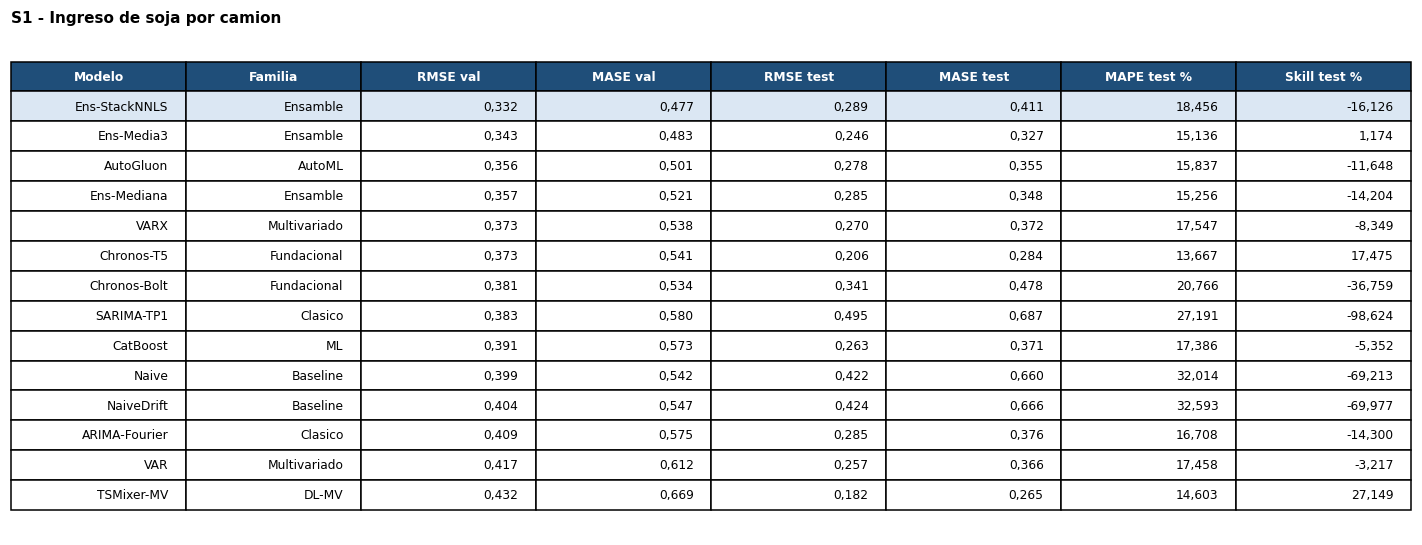

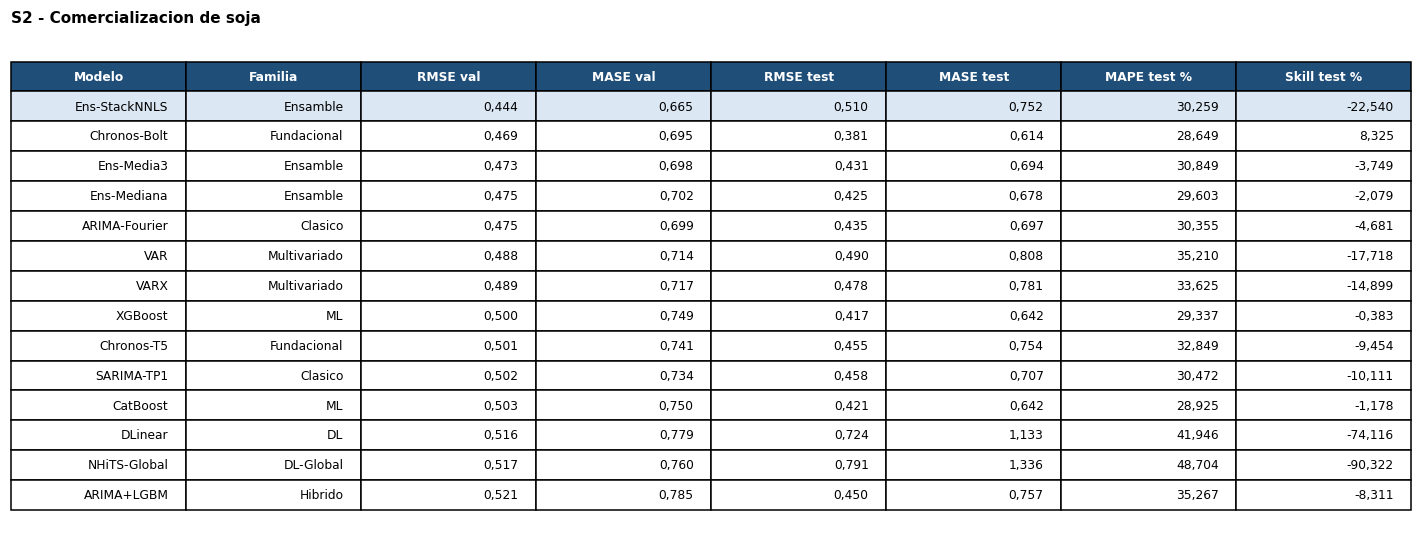

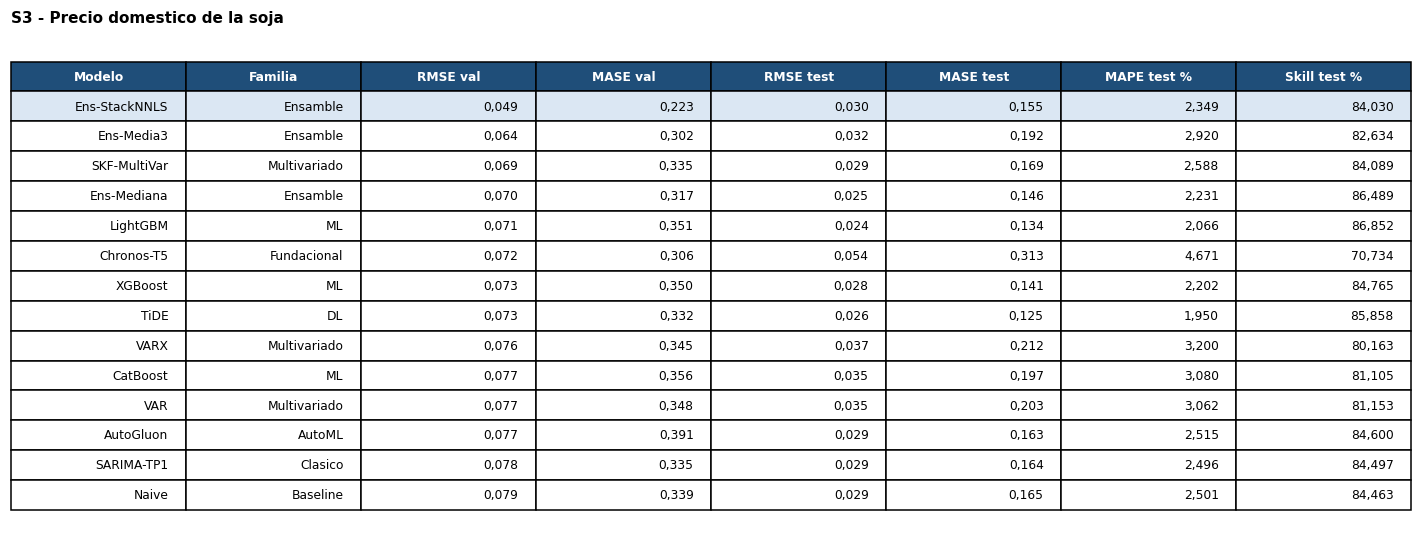

In [ ]:
def tabla_imagen(t, titulo, fname, n=14):
    d = t.head(n).copy()
    for c in d.columns:
        if d[c].dtype.kind == "f":
            d[c] = d[c].map(lambda v: "—" if pd.isna(v) else f"{v:,.3f}"
                            .replace(",", "X").replace(".", ",").replace("X", "."))
    fig, ax = plt.subplots(figsize=(1.0 + 1.5 * d.shape[1], 0.55 + 0.32 * len(d)))
    ax.axis("off")
    tb = ax.table(cellText=d.values, colLabels=[NOMBRES.get(c, c) for c in d.columns],
                  cellLoc="right", loc="center")
    tb.auto_set_font_size(False); tb.set_fontsize(8); tb.scale(1, 1.4)
    for (i, j), celda in tb.get_celld().items():
        if i == 0:
            celda.set_facecolor("#1f4e79")
            celda.set_text_props(color="white", fontweight="bold")
        elif i == 1:
            celda.set_facecolor("#dbe7f3")
    ax.set_title(titulo, fontweight="bold", fontsize=10, pad=10, loc="left")
    fig.tight_layout()
    fig.savefig(f"{FIGS}/{fname}", dpi=200, bbox_inches="tight")
    plt.show()

for sid, cfg in SERIES.items():
    tabla_imagen(tablas[sid], cfg["etiq"], f"tabla_metricas_{sid}.png")

### 9.3 Estabilidad entre pliegue
Un modelo que gana en promedio pero es errático no sirve en producción. El promedio sobre 104 puntos puede estar dominado por un solo pliegue afortunado, y el diagrama de cajas del RMSE por pliegue lo revela de inmediato. El **ranking promedio** —posición media del modelo entre los ocho pliegues— es un criterio complementario y no paramétrico: no le importa la magnitud del error sino la consistencia con que un modelo le gana a los demás.

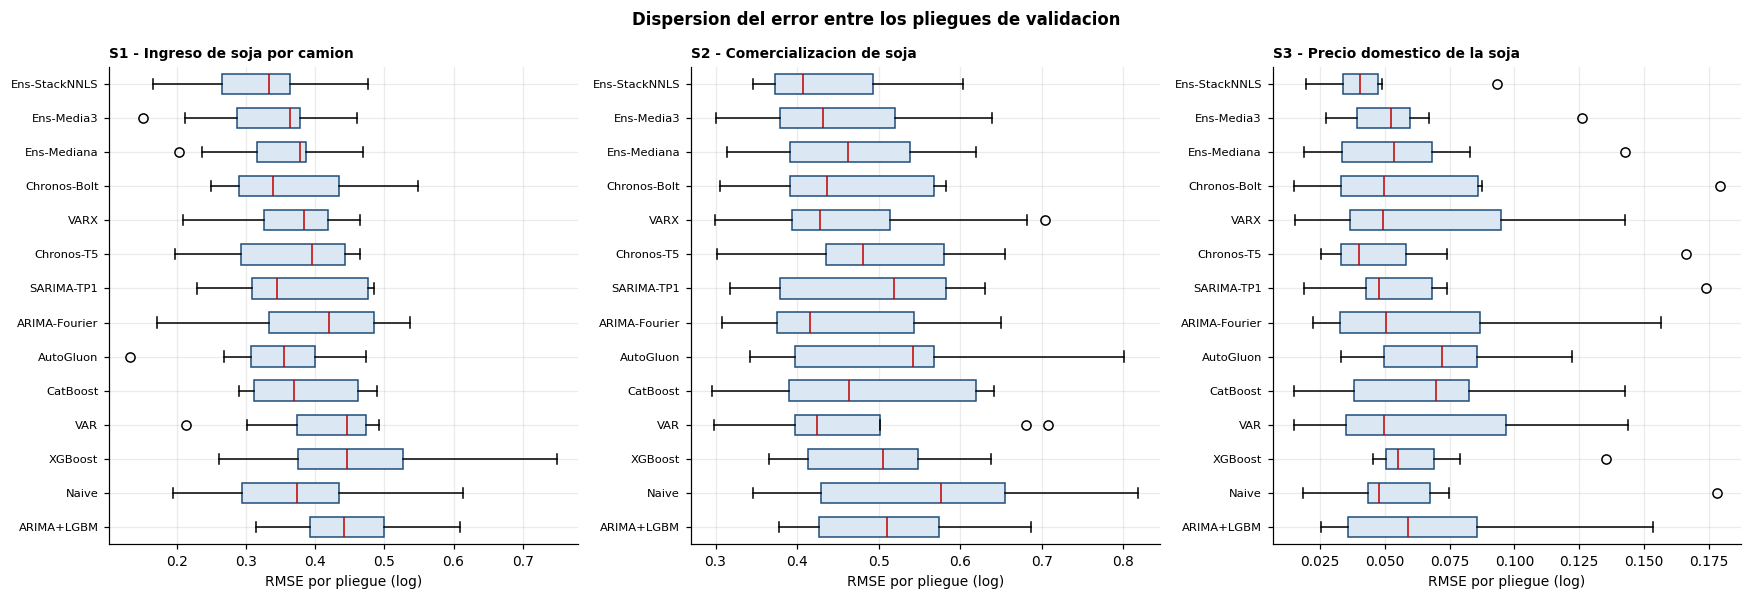

In [ ]:
orden_glob = (resultados.groupby("modelo")["val_rmse_log"].mean()
              .sort_values().index.tolist())

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (sid, cfg) in zip(axes, SERIES.items()):
    d = por_pliegue.query("serie == @sid")
    mods = [m for m in orden_glob if m in set(d.modelo)][:14]
    datos = [d.query("modelo == @m")["rmse_log"].dropna().values for m in mods]
    bp = ax.boxplot(datos, vert=False, labels=mods, patch_artist=True, widths=.6)
    for caja in bp["boxes"]:
        caja.set_facecolor("#dbe7f3"); caja.set_edgecolor(AZUL)
    for mediana in bp["medians"]:
        mediana.set_color(ROJO)
    ax.invert_yaxis(); ax.set_xlabel("RMSE por pliegue (log)")
    ax.set_title(cfg["etiq"], loc="left", fontweight="bold", fontsize=9)
    ax.tick_params(axis="y", labelsize=7.5)
fig.suptitle("Dispersion del error entre los pliegues de validacion", fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIGS}/fig04_boxplot_pliegues.png", bbox_inches="tight")
plt.show()

In [ ]:
# --- Ranking promedio entre pliegues (criterio no parametrico de consistencia)
rk = (por_pliegue.pivot_table(index=["serie", "pliegue"], columns="modelo",
                              values="rmse_log")
      .rank(axis=1, method="average"))
ranking = pd.concat([rk.groupby(level=0).mean().T,
                     rk.mean().rename("Promedio")], axis=1)
ranking = ranking.sort_values("Promedio")
ranking.to_csv(f"{OUT}/ranking_promedio.csv")
print("Ranking promedio entre pliegues (1 = mejor). Columna 'Promedio' sobre las 3 series:\n")
print(ranking.round(2).head(20).to_string())

Ranking promedio entre pliegues (1 = mejor). Columna 'Promedio' sobre las 3 series:

                  S1     S2     S3  Promedio
modelo                                      
Ens-StackNNLS   7.00   7.12   4.88      6.33
Ens-Media3      7.00  10.62  11.88      9.83
Ens-Mediana     9.75  10.50  10.62     10.29
VARX           11.88  11.88  13.12     12.29
Chronos-T5     10.75  14.62  11.62     12.33
Chronos-Bolt   13.75  10.12  14.12     12.67
SARIMA-TP1     12.50  12.62  12.88     12.67
ARIMA-Fourier  14.38  11.50  13.88     13.25
VAR            15.88  11.75  12.88     13.50
AutoGluon       8.75  14.62  17.25     13.54
CatBoost       13.00  13.12  14.62     13.58
FourTheta      17.12  13.88  13.88     14.96
Naive          11.62  20.00  13.25     14.96
HoltWinters    17.50  14.25  13.75     15.17
Theta          17.88  14.12  13.88     15.29
NaiveDrift     12.12  21.50  14.00     15.88
SKF-MultiVar   16.12  19.12  13.62     16.29
XGBoost        19.12  15.62  15.62     16.79
TSMixer-MV     

### 9.4 ¿Las diferencias son significativas? Contraste de Diebold-Mariano

Que un modelo tenga un RMSE menor que otro no implica que sea mejor: puede ser ruido muestral. El contraste de Diebold y Mariano (1995) evalúa formalmente la hipótesis nula de **igual precisión predictiva**, comparando la serie de diferencias de pérdida `d_t = L(e¹_t) − L(e²_t)`. Se aplica la corrección de muestras pequeñas de Harvey, Leybourne y Newbold (1997), necesaria porque los errores de pronóstico a `h` pasos están autocorrelacionados por construcción hasta el orden `h−1`.El contraste se aplica sobre las **104 observaciones de validación**, no sobre las 13 del test: contrece puntos el contraste carece de potencia y no rechazaría prácticamente nada.

In [ ]:
def diebold_mariano(e1, e2, h=H, potencia=2):
    '''DM con correccion de Harvey-Leybourne-Newbold. Devuelve (estadistico, p-valor).'''
    d = np.abs(e1) ** potencia - np.abs(e2) ** potencia
    n = len(d)
    d_barra = d.mean()
    # Varianza de largo plazo truncada en h-1 rezagos
    gamma = [np.sum((d[:n - k] - d_barra) * (d[k:] - d_barra)) / n for k in range(h)]
    V = (gamma[0] + 2 * np.sum(gamma[1:])) / n
    if V <= 0:
        return np.nan, np.nan
    dm = d_barra / np.sqrt(V)
    correccion = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm_corr = dm * correccion
    p = 2 * (1 - st.t.cdf(abs(dm_corr), df=n - 1))
    return float(dm_corr), float(p)


filas_dm = []
for sid in SERIES:
    mejor = tablas[sid]["modelo"].iloc[0]
    Yv, Pbase = matriz_predicciones(sid, "val", [mejor])
    e_mejor = Yv - Pbase[:, 0]
    for m in tablas[sid]["modelo"]:
        if m == mejor:
            continue
        Pm = matriz_predicciones(sid, "val", [m])[1][:, 0]
        if np.isnan(Pm).any():
            continue
        dm, p = diebold_mariano(e_mejor, Yv - Pm)
        filas_dm.append(dict(serie=sid, referencia=mejor, modelo=m,
                             DM=dm, p_valor=p,
                             conclusion=("indistinguible del mejor" if p > 0.10 else
                                         "peor que el mejor (5 %)" if p < 0.05 else
                                         "peor que el mejor (10 %)")))

dm_tab = pd.DataFrame(filas_dm)
dm_tab.to_csv(f"{OUT}/diebold_mariano.csv", index=False)
for sid in SERIES:
    d = dm_tab.query("serie == @sid").sort_values("p_valor", ascending=False)
    print(f"\n{sid} — referencia: {d['referencia'].iloc[0] if len(d) else '—'}")
    print(d[["modelo", "DM", "p_valor", "conclusion"]].head(8)
          .to_string(index=False, float_format=lambda v: f"{v:7.4f}"))


S1 — referencia: Ens-StackNNLS
      modelo      DM  p_valor               conclusion
  Ens-Media3 -0.7292   0.4675 indistinguible del mejor
   AutoGluon -0.7816   0.4362 indistinguible del mejor
Chronos-Bolt -1.0642   0.2897 indistinguible del mejor
      N-HiTS -1.1524   0.2518 indistinguible del mejor
        LSTM -1.2626   0.2096 indistinguible del mejor
  Chronos-T5 -1.3425   0.1824 indistinguible del mejor
       Naive -1.4755   0.1431 indistinguible del mejor
  NaiveDrift -1.5355   0.1277 indistinguible del mejor

S2 — referencia: Ens-StackNNLS
       modelo      DM  p_valor               conclusion
 Chronos-Bolt -0.7875   0.4328 indistinguible del mejor
   Ens-Media3 -0.8702   0.3862 indistinguible del mejor
ARIMA-Fourier -0.9802   0.3293 indistinguible del mejor
          VAR -0.9967   0.3212 indistinguible del mejor
         VARX -1.0280   0.3064 indistinguible del mejor
  Ens-Mediana -1.3573   0.1776 indistinguible del mejor
 NHiTS-Global -1.3602   0.1767 indistinguible del

### 9.5 Gráficos comparativos sobre el hold-out

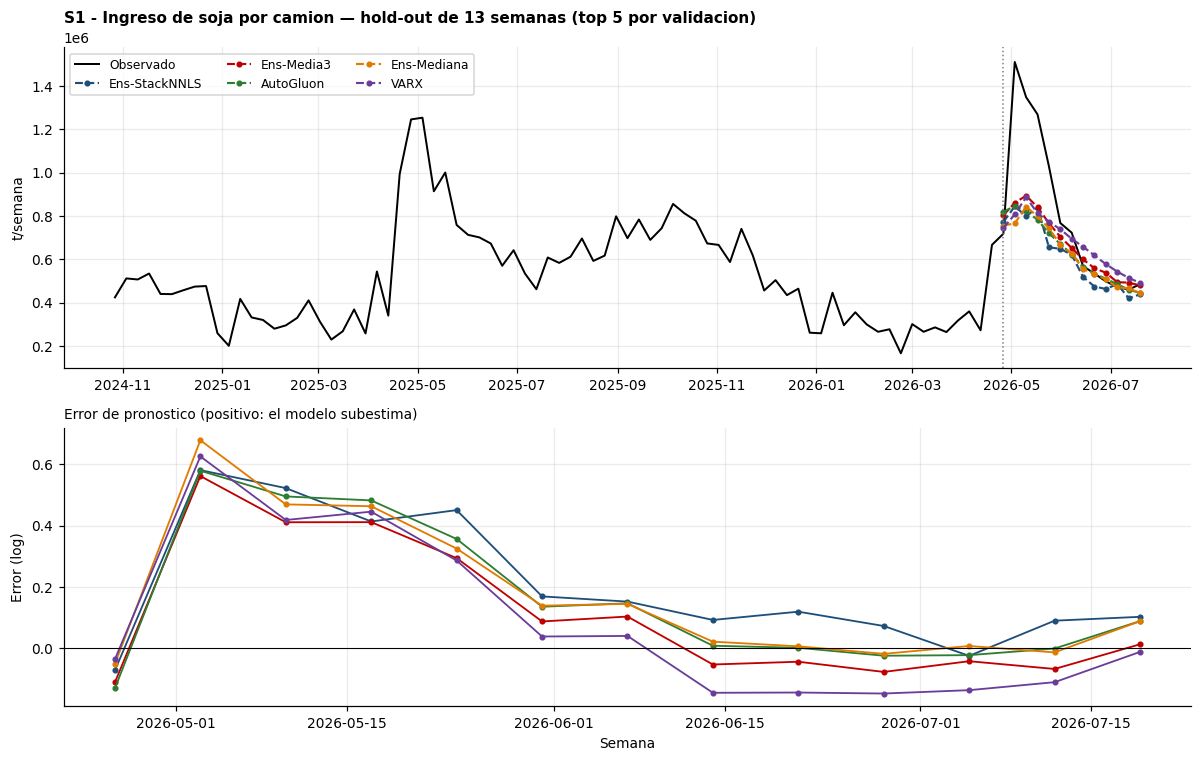

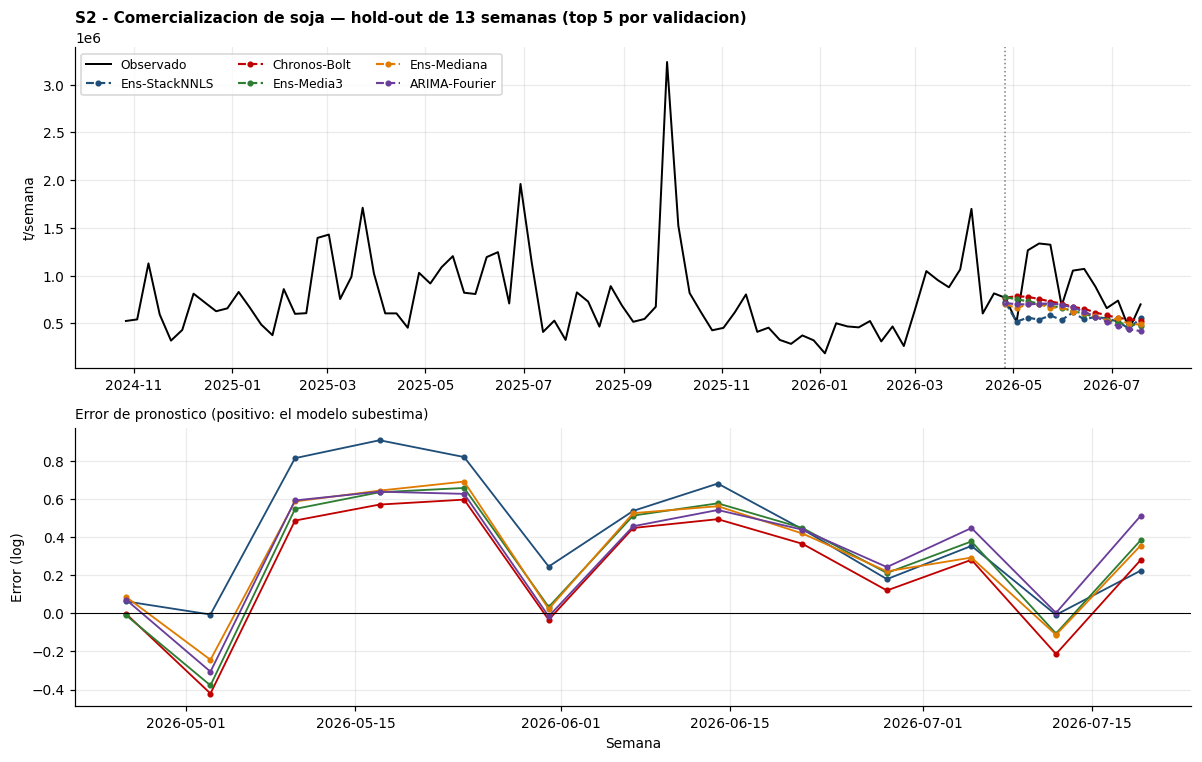

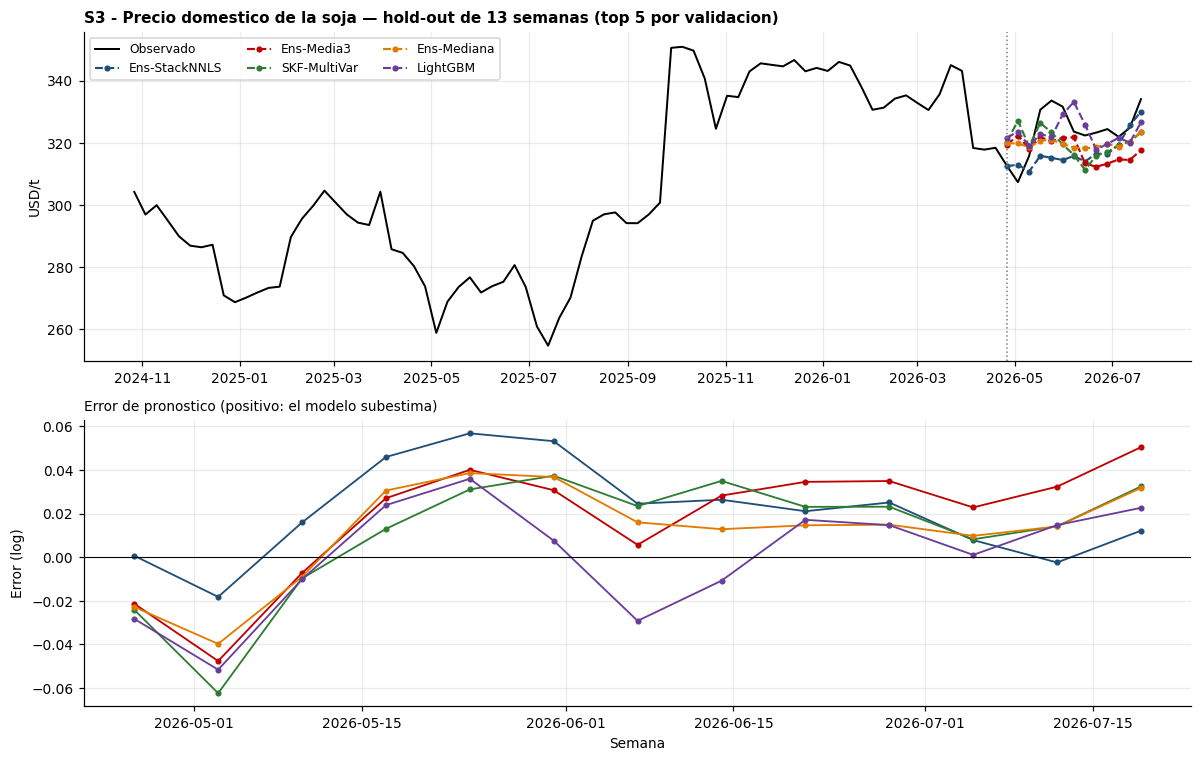

In [ ]:
VENTANA_HIST, TOP_K = 78, 5

for sid, cfg in SERIES.items():
    mejores = tablas[sid].dropna(subset=["test_rmse_log"])["modelo"].head(TOP_K).tolist()
    fig, axes = plt.subplots(2, 1, figsize=(11, 7),
                             gridspec_kw={"height_ratios": [1.15, 1]})
    ax = axes[0]
    hist = np.exp(log_panel[f"l{cfg['col']}"].iloc[FIN_TRAIN - VENTANA_HIST:])
    ax.plot(hist.index, hist.values, color="black", lw=1.3, label="Observado")
    for k, m in enumerate(mejores):
        p = PRED.get((sid, m, "test", 0))
        if p is None or np.isnan(p).any():
            continue
        ax.plot(idx[FIN_TRAIN:], np.exp(p), lw=1.4, ls="--", marker="o", ms=3,
                color=PALETA[k % len(PALETA)], label=m)
    ax.axvline(idx[FIN_TRAIN], color=GRIS, ls=":", lw=1)
    ax.set_ylabel(cfg["unidad"]); ax.legend(ncol=3, fontsize=8)
    ax.set_title(f"{cfg['etiq']} — hold-out de {H} semanas (top {TOP_K} por validacion)",
                 loc="left", fontweight="bold", fontsize=10)

    ax = axes[1]
    real = real_de(sid, FIN_TRAIN)
    for k, m in enumerate(mejores):
        p = PRED.get((sid, m, "test", 0))
        if p is None or np.isnan(p).any():
            continue
        ax.plot(idx[FIN_TRAIN:], real - p, lw=1.2, marker="o", ms=3,
                color=PALETA[k % len(PALETA)], label=m)
    ax.axhline(0, color="black", lw=.7)
    ax.set_ylabel("Error (log)"); ax.set_xlabel("Semana")
    ax.set_title("Error de pronostico (positivo: el modelo subestima)", loc="left", fontsize=9)
    fig.tight_layout()
    fig.savefig(f"{FIGS}/fig05_pronostico_{sid}.png", bbox_inches="tight")
    plt.show()

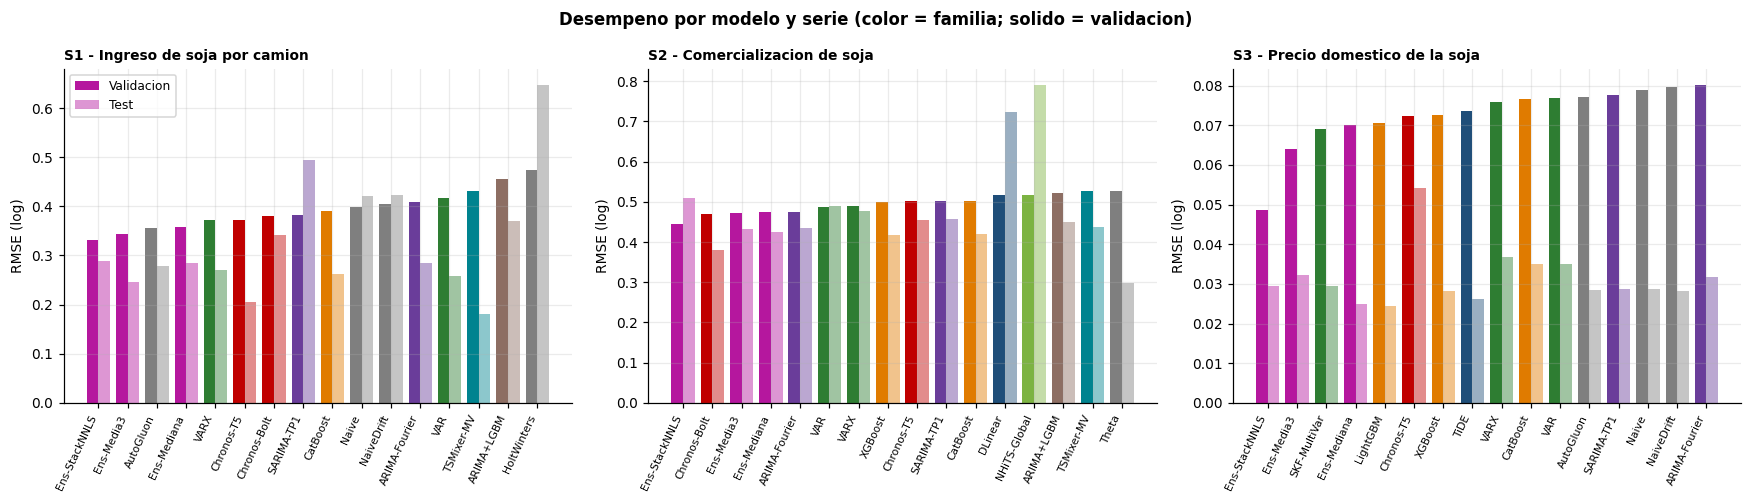

In [ ]:
# --- Barras por familia: validacion contra test
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
COLOR_FAM = {"Baseline": GRIS, "Clasico": "#6a3d9a", "Multivariado": VERDE, "ML": "#e07b00",
             "DL": AZUL, "DL-MV": "#00838f", "DL-Global": "#7cb342",
             "Hibrido": "#8d6e63", "Fundacional": ROJO, "Ensamble": "#b5179e"}
for ax, (sid, cfg) in zip(axes, SERIES.items()):
    t = tablas[sid].dropna(subset=["val_rmse_log"]).head(16)
    x = np.arange(len(t))
    ax.bar(x - .2, t["val_rmse_log"], width=.4,
           color=[COLOR_FAM.get(f, GRIS) for f in t["familia"]], label="Validacion")
    ax.bar(x + .2, t["test_rmse_log"], width=.4,
           color=[COLOR_FAM.get(f, GRIS) for f in t["familia"]], alpha=.45, label="Test")
    ax.set_xticks(x); ax.set_xticklabels(t["modelo"], rotation=65, ha="right", fontsize=7)
    ax.set_ylabel("RMSE (log)")
    ax.set_title(cfg["etiq"], loc="left", fontweight="bold", fontsize=9)
axes[0].legend(fontsize=8)
fig.suptitle("Desempeno por modelo y serie (color = familia; solido = validacion)",
             fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIGS}/fig06_rmse_barras.png", bbox_inches="tight")
plt.show()

### 9.6 Comparación con el TP1
Los valores de las Tablas 10 a 12 del informe del TP1, sobre 121 semanas de testeo desde el 31 demarzo de 2024.
Dos advertencias. Primera: los RMSE de 121 semanas no son homologables con los de un hold-out de 13; la columna `TP1_RMSE_h13_ventana_fija` —el error del SARIMA adoptado restringido a las trece primeras semanas de aquel testeo— es la referencia más cercana en horizonte, aunque corresponda a otro tramo del calendario. Segunda: el esquema de origen móvil mide un problema distinto—pronóstico a un paso con reajuste continuo— y por construcción arroja errores mucho menores; se incluye para dimensionar cuánto del error proviene del horizonte y no del modelo.La comparación estrictamente homogénea es la de `ARIMA-Fourier` y `SARIMA-TP1`, reestimados aquí sobre exactamente los mismos pliegues que el resto.

In [ ]:
REF_TP1 = pd.DataFrame({
    "serie": ["S1", "S2", "S3"],
    "TP1_SARIMA_ventana_fija":        [0.5363, 0.4852, 0.0937],
    "TP1_SARIMA_origen_movil_h1":     [0.3133, 0.4182, 0.0262],
    "TP1_naive_RW_origen_movil_h1":   [0.3486, 0.4936, 0.0263],
    "TP1_naive_estacional_lag52":     [0.6744, 0.7156, 0.1565],
    "TP1_ARIMA_Fourier_ventana_fija": [0.3987, 0.4672, 0.0823],
    "TP1_RMSE_h13_ventana_fija":      [0.8130, 0.4379, 0.0346],
})

mejor_tp2 = (resultados.dropna(subset=["val_rmse_log"])
             .sort_values("val_rmse_log").groupby("serie", as_index=False).first()
             [["serie", "modelo", "familia", "test_rmse_log", "test_mase", "test_mape_niv"]]
             .rename(columns={"modelo": "TP2_mejor", "familia": "TP2_familia",
                              "test_rmse_log": "TP2_RMSE_test",
                              "test_mase": "TP2_MASE_test",
                              "test_mape_niv": "TP2_MAPE_test_%"}))

comparacion = REF_TP1.merge(mejor_tp2, on="serie")
comparacion.to_csv(f"{OUT}/comparacion_tp1_tp2.csv", index=False)
comparacion.round(4)

,serie,TP1_SARIMA_ventana_fija,TP1_SARIMA_origen_movil_h1,TP1_naive_RW_origen_movil_h1,TP1_naive_estacional_lag52,TP1_ARIMA_Fourier_ventana_fija,TP1_RMSE_h13_ventana_fija,TP2_mejor,TP2_familia,TP2_RMSE_test,TP2_MASE_test,TP2_MAPE_test_%
0,S1,0.5363,0.3133,0.3486,0.6744,0.3987,0.8130,Ens-StackNNLS,Ensamble,0.2895,0.4109,18.4558
1,S2,0.4852,0.4182,0.4936,0.7156,0.4672,0.4379,Ens-StackNNLS,Ensamble,0.5096,0.7519,30.2593
2,S3,0.0937,0.0262,0.0263,0.1565,0.0823,0.0346,Ens-StackNNLS,Ensamble,0.0296,0.1555,2.3488


---
## 10. Modelo seleccionado y pronóstico ex ante

El modelo elegido para cada serie es el de menor **RMSE de validación**. Se lo re ajusta con la muestra completa —incluidas las últimas trece semanas— y se pronostican las trece siguientes al último dato disponible. Si el modelo ganador resulta ser un **ensamble**, el pronóstico ex ante se construye reajustando sus componentes sobre la muestra completa y aplicando **los pesos fijados en validación**. Los pesos no se recalculan: hacerlo con la muestra completa incorporaría el hold-out a la determinación del ensamble, que es exactamente lo que la sección 8 evita. Reajustar varias arquitecturas puede demorar algunos minutos.

**Intervalos.** En lugar de los intervalos paramétricos del modelo —que no todos los modelos proveen y que descansan en supuestos distintos en cada familia—, se construyen bandas **empíricas**a partir de la distribución de los errores de validación **por paso del horizonte**: para cada`k = 1, …, 13` se estima el desvío del error a `k` pasos sobre los ocho pliegues y se aplica`±1,96 σ_k`. El procedimiento es agnóstico al modelo, refleja el error efectivamente cometido e ncondiciones de pronóstico real, y captura el ensanchamiento con el horizonte sin imponerle forma funcional.

In [ ]:
criterio = "val_rmse_log"
SELECCION = (resultados.dropna(subset=[criterio])
             .sort_values(criterio).groupby("serie").first()["modelo"].to_dict())
print("Modelo seleccionado por serie (menor RMSE de validacion):")
for sid, m in SELECCION.items():
    r = resultados.query("serie == @sid and modelo == @m").iloc[0]
    print(f"  {sid}: {m:16s} [{FAMILIA.get(m,'')}]  RMSE val = {r[criterio]:.4f}  "
          f"MASE val = {r['val_mase']:.3f}")

Modelo seleccionado por serie (menor RMSE de validacion):
  S1: Ens-StackNNLS    [Ensamble]  RMSE val = 0.3317  MASE val = 0.477
  S2: Ens-StackNNLS    [Ensamble]  RMSE val = 0.4436  MASE val = 0.665
  S3: Ens-StackNNLS    [Ensamble]  RMSE val = 0.0487  MASE val = 0.223


In [ ]:
def sigma_por_paso(sid, modelo):
    '''Desvio del error a k pasos, estimado sobre los pliegues de validacion.'''
    E = []
    for _, j, o in PLIEGUES[:-1]:
        p = PRED.get((sid, modelo, "val", j))
        if p is not None and not np.isnan(p).any():
            E.append(real_de(sid, o) - p)
    E = np.array(E)
    return E.std(axis=0, ddof=1) if len(E) > 2 else np.full(H, np.nan)


if not RECETA_ENS and os.path.exists(RUTA_RECETAS):
    RECETA_ENS = json.load(open(RUTA_RECETAS))


def pronostico_ex_ante(sid, nombre, h=H):
    '''Reajusta con la muestra completa y pronostica h pasos.'''
    # Un ensamble se reconstruye reajustando sus componentes y aplicando la receta
    # fijada en validacion. Los pesos NO se recalculan aqui: hacerlo con la muestra
    # completa usaria el hold-out, que es justamente lo que la seccion 8 evita.
    if nombre.startswith("Ens-"):
        r = RECETA_ENS[sid]
        if nombre == "Ens-Media3":
            comps, pesos = r["top3"], np.full(3, 1 / 3)
        elif nombre == "Ens-StackNNLS":
            w = np.asarray(r["pesos"], dtype=float)
            sel = w > 0.01                       # componentes con peso no trivial
            comps = [m for m, k in zip(r["modelos"], sel) if k]
            pesos = w[sel] / w[sel].sum()
        else:                                    # Ens-Mediana: exige todos
            comps, pesos = r["modelos"], None
        print(f"    [{sid}] {nombre} reajusta {len(comps)} componentes: {comps}")
        P = np.column_stack([pronostico_ex_ante(sid, m, h) for m in comps])
        return np.median(P, axis=1) if pesos is None else P @ pesos

    if nombre in ("ARIMA-Fourier", "SARIMA-TP1"):
        return ajustar_arima(sid, N, h, estacional=(nombre == "SARIMA-TP1"))
    if nombre == "ARIMA+LGBM":
        return ajustar_predecir_hibrido(sid, N, h)
    if nombre == "SKF-MultiVar":
        return ajustar_predecir_skf(sid, N, h)
    if nombre in ("VAR", "VARX"):
        return ajustar_predecir_var(N, h, con_exog=(nombre == "VARX"))[sid]
    if nombre in ("TSMixer-MV", "TiDE-MV"):
        return ajustar_predecir_mv(nombre, N, h)[sid]
    if nombre == "NHiTS-Global":
        return ajustar_predecir_global(N, h)[sid]
    if nombre == "Chronos-T5":
        return predecir_chronos(CHRONOS_MODELO, sid, N, h)
    if nombre == "Chronos-Bolt":
        return predecir_chronos(BOLT_MODELO, sid, N, h)
    if nombre == "AutoGluon":
        return ajustar_predecir_autogluon(sid, N, h)
    return predecir_uni(nombre, sid, N, h)


idx_fut, futuro, bandas = idx_ext[N:N + H], {}, {}
for sid, nombre in SELECCION.items():
    try:
        futuro[sid] = pronostico_ex_ante(sid, nombre)
        bandas[sid] = sigma_por_paso(sid, nombre)
        print(f"  {sid} ({nombre}): OK")
    except Exception as e:
        print(f"  {sid} ({nombre}): FALLO -> {repr(e)[:140]}")
        futuro[sid] = np.full(H, np.nan); bandas[sid] = np.full(H, np.nan)

df_fut = pd.DataFrame(index=idx_fut)
for sid, cfg in SERIES.items():
    c = cfg["col"]
    df_fut[f"{c}_log"]   = futuro[sid]
    df_fut[f"{c}_nivel"] = np.exp(futuro[sid])
    df_fut[f"{c}_lo95"]  = np.exp(futuro[sid] - 1.96 * bandas[sid])
    df_fut[f"{c}_hi95"]  = np.exp(futuro[sid] + 1.96 * bandas[sid])
df_fut.index.name = "semana"
df_fut.to_csv(f"{OUT}/pronostico_futuro.csv")
df_fut.filter(regex="nivel|lo95|hi95").round(1)

    [S1] Ens-StackNNLS reajusta 7 componentes: ['AutoGluon', 'DLinear', 'N-BEATS', 'NHiTS-Global', 'SARIMA-TP1', 'TSMixer', 'TSMixer-MV']


INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157d53/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2/60088152a34e242427b44c3100014473a0157

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

...

INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 538 samples.
INFO:darts.models.forecasting.torch_forecasting_model:Time series values are 32-bits; casting model to float32.
INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 538 samples.
INFO:darts.models.forecasting.torch_forecasting_model:Time series values are 32-bits; casting model to float32.
INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 538 samples.
INFO:darts.models.forecasting.torch_forecasting_model:Time series values are 32-bits; casting model to float32.


  S2 (Ens-StackNNLS): OK
    [S3] Ens-StackNNLS reajusta 5 componentes: ['DLinear', 'LSTM', 'Prophet', 'SKF-MultiVar', 'TSMixer']


INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 538 samples.
INFO:darts.models.forecasting.torch_forecasting_model:Time series values are 32-bits; casting model to float32.
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 538 samples.
INFO:darts.models.forecasting.torch_forecasting_model:Time series values are 32-bits; casting model to float32.


  S3 (Ens-StackNNLS): OK


,camiones_nivel,camiones_lo95,camiones_hi95,comercializacion_nivel,comercializacion_lo95,comercializacion_hi95,precio_nivel,precio_lo95,precio_hi95
semana,,,,,,,,,
2026-07-26,398497.1,286746.5,553799.1,550669.2,288321.2,1051732.0,339.9,330.6,349.5
2026-08-02,400463.7,301382.6,532118.2,525418.8,325261.7,848747.2,344.0,321.1,368.6
2026-08-09,415301.8,129553.6,1331306.4,515333.5,200252.7,1326167.3,350.1,326.7,375.1
2026-08-16,434945.3,265987.5,711226.8,591257.7,250500.1,1395550.9,350.5,327.4,375.1
2026-08-23,448845.2,219035.5,919768.7,558874.8,223293.3,1398792.3,357.5,333.0,383.9
2026-08-30,442258.5,289356.7,675956.8,565545.6,288131.0,1110056.7,358.2,329.6,389.4
2026-09-06,497892.0,272622.5,909303.1,732606.5,355372.0,1510282.9,360.4,337.2,385.1
2026-09-13,454305.3,242901.7,849698.8,741434.2,326177.8,1685352.7,361.9,339.9,385.3
2026-09-20,497315.4,297265.0,831993.6,765006.7,363757.3,1608862.1,366.1,340.0,394.2


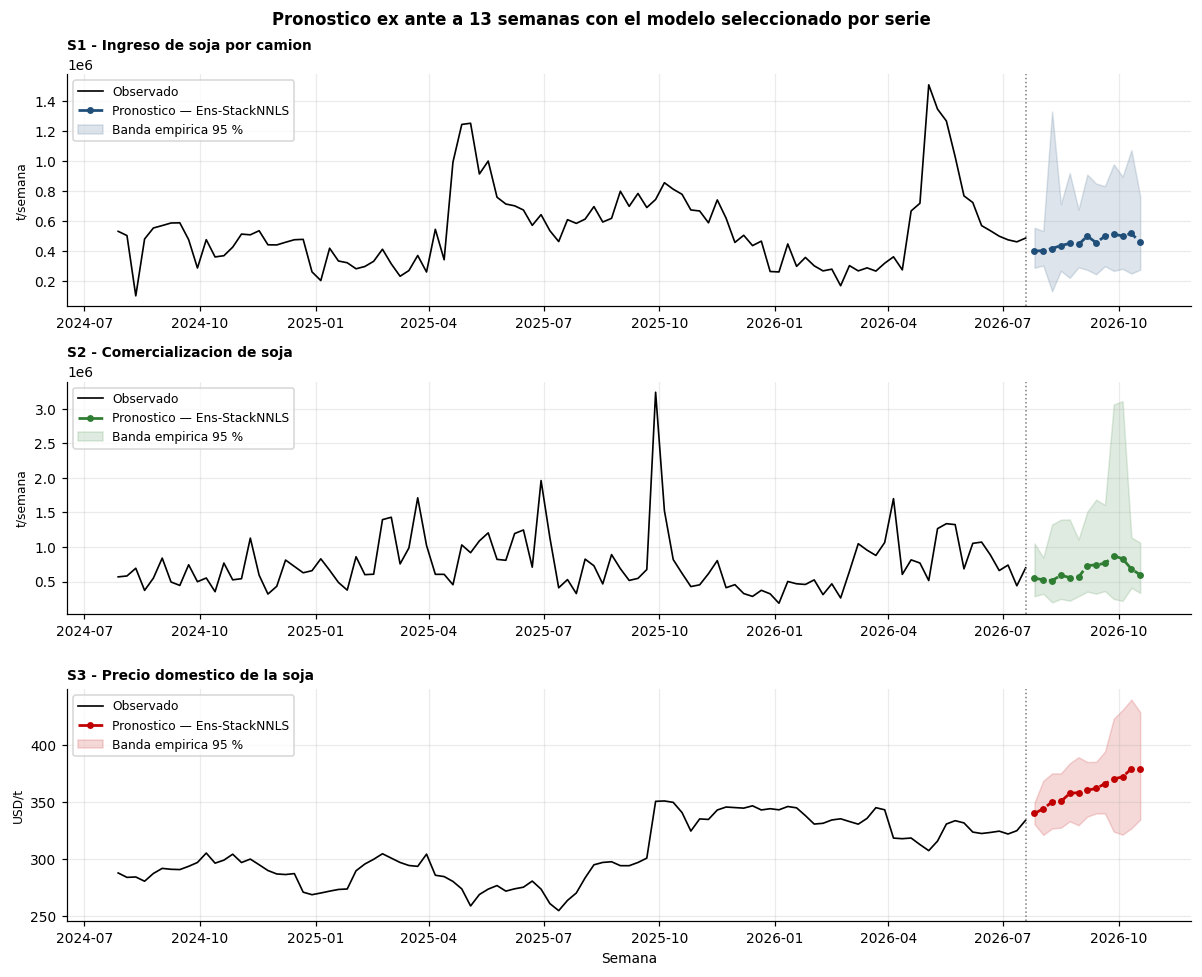

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9))
for ax, (sid, cfg), color in zip(axes, SERIES.items(), [AZUL, VERDE, ROJO]):
    hist = np.exp(log_panel[f"l{cfg['col']}"].iloc[-104:])
    ax.plot(hist.index, hist.values, color="black", lw=1.1, label="Observado")
    ax.plot(idx_fut, np.exp(futuro[sid]), color=color, lw=1.8, ls="--", marker="o", ms=3.5,
            label=f"Pronostico — {SELECCION[sid]}")
    ax.fill_between(idx_fut, np.exp(futuro[sid] - 1.96 * bandas[sid]),
                    np.exp(futuro[sid] + 1.96 * bandas[sid]),
                    color=color, alpha=.15, label="Banda empirica 95 %")
    ax.axvline(log_panel.index[-1], color=GRIS, ls=":", lw=1)
    ax.set_ylabel(cfg["unidad"], fontsize=8); ax.legend(fontsize=8)
    ax.set_title(cfg["etiq"], loc="left", fontweight="bold", fontsize=9)
axes[-1].set_xlabel("Semana")
fig.suptitle(f"Pronostico ex ante a {H} semanas con el modelo seleccionado por serie",
             fontweight="bold")
fig.tight_layout()
fig.savefig(f"{FIGS}/fig07_pronostico_futuro.png", bbox_inches="tight")
plt.show()

---
## 11. AutoML — AutoGluon TimeSeries (bloque final, sesión aparte)

> **Ejecutar esto último y, preferentemente, después de reiniciar el entorno.** AutoGluon reemplaza
> las versiones de `torch` y `pytorch-lightning` que Darts necesita, de modo que correrlo antes
> rompe todo lo anterior. Como los pronósticos están cacheados en Drive, el flujo correcto es:
> terminar las secciones 1 a 10 → reiniciar el entorno → ejecutar las celdas de configuración y> datos (secciones 0.2 a 3) → ejecutar este bloque → volver a la sección 9 para recalcular las> tablas ya con AutoGluon incluido.

AutoGluon explora automáticamente una familia amplia —modelos estadísticos, árboles, DeepAR, TFT y el propio Chronos— y construye un ensamble ponderado por validación interna. Con`presets="best_quality"` incluye Chronos afinado sobre la serie, lo que lo convierte en lacomparación natural contra el Chronos zero-shot de la sección 7. Se lo evalúa sobre **todos los pliegues** para que la comparación sea homogénea. Con`time_limit=420` segundos por ajuste, el bloque demora del orden de 45 a 60 minutos.

In [ ]:
%pip install -q autogluon.timeseries
import IPython
IPython.get_ipython().kernel.do_shutdown(True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.4/274.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.0/864.0 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

{'status': 'ok', 'restart': True}

In [ ]:
import os, json, time, pickle, gc, warnings
import numpy as np, pandas as pd, torch
warnings.simplefilter("ignore")

from google.colab import drive
drive.mount("/content/drive")

OUT  = "/content/drive/MyDrive/Series_Temporales/out_tp2"
M, FREQ, H, N_PLIEGUES = 52, "W-SUN", 13, 8
SERIES = {"S1": dict(col="camiones"), "S2": dict(col="comercializacion"),
          "S3": dict(col="precio")}

# Panel en logaritmos, tal como lo dejo la seccion 1
log_panel = pd.read_csv(f"{OUT}/panel_log.csv", index_col=0, parse_dates=True).asfreq(FREQ)
idx = log_panel.index
N = len(log_panel); FIN_TRAIN = N - H
ORIGENES = [FIN_TRAIN - (N_PLIEGUES - j) * H for j in range(N_PLIEGUES)]
PLIEGUES = [("val", j, o) for j, o in enumerate(ORIGENES)] + [("test", 0, FIN_TRAIN)]

RUTA_CACHE, RUTA_FAM = f"{OUT}/predicciones_v2.pkl", f"{OUT}/familias_v2.json"
PRED    = pickle.load(open(RUTA_CACHE, "rb"))
FAMILIA = json.load(open(RUTA_FAM)) if os.path.exists(RUTA_FAM) else {}
ERRORES = []

def guardar_cache():
    pickle.dump(PRED, open(RUTA_CACHE, "wb"))
    json.dump(FAMILIA, open(RUTA_FAM, "w"), indent=1)

def correr(nombre, fn, fam="", forzar=False):
    FAMILIA[nombre] = fam
    t0, n_err = time.time(), 0
    for sid in SERIES:
        for tipo, j, o in PLIEGUES:
            clave = (sid, nombre, tipo, j)
            if clave in PRED and not forzar:
                continue
            try:
                PRED[clave] = np.asarray(fn(sid, o), dtype=float)
            except Exception as e:
                ERRORES.append((sid, nombre, tipo, j, repr(e)[:180])); n_err += 1
                PRED[clave] = np.full(H, np.nan)
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            guardar_cache()          # guarda despues de cada ajuste: si Colab corta, no se pierde
    print(f"  {nombre:18s} {time.time()-t0:7.1f} s" + (f"  [{n_err} errores]" if n_err else ""))

print(f"Cache: {len(PRED)} pronosticos | {N} semanas | hold-out desde {idx[FIN_TRAIN].date()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cache: 810 pronosticos | 602 semanas | hold-out desde 2026-04-26


In [ ]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
TIEMPO_AUTOML = 240          # segundos por ajuste: 27 ajustes -> ~1h50

def ajustar_predecir_autogluon(sid, fin_train, h=H):
    s = log_panel[f"l{SERIES[sid]['col']}"].iloc[:fin_train]
    df = pd.DataFrame({"item_id": "serie", "timestamp": s.index, "target": s.values})
    tsdf = TimeSeriesDataFrame.from_data_frame(df, id_column="item_id",
                                               timestamp_column="timestamp")
    pred = TimeSeriesPredictor(
        prediction_length=h, target="target", eval_metric="RMSE", freq=FREQ,
        verbosity=0, path=f"/tmp/ag_{sid}_{fin_train}",
    ).fit(tsdf, presets="best_quality", time_limit=TIEMPO_AUTOML)
    return pred.predict(tsdf)["mean"].to_numpy()

correr("AutoGluon", ajustar_predecir_autogluon, fam="AutoML")

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-s

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/trainer/trainer.py", line 362, in _train_and_save
    model.fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        refit_every_n_windows=self.refit_every_n_windows,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 580, in fit
    self._fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        **(self._get_system_resources() | kwargs),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 147, in _fit
    model.fit(
    ~~~~~~~~~^
        train_data=train_fold,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

  AutoGluon           4434.0 s


In [ ]:
CORRER_AUTOML = True          # poner True tras reiniciar el entorno
TIEMPO_AUTOML = 420            # segundos por ajuste

if CORRER_AUTOML:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "autogluon.timeseries"], check=True)
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

    def ajustar_predecir_autogluon(sid, fin_train, h=H):
        s = log_panel[f"l{SERIES[sid]['col']}"].iloc[:fin_train]
        df = pd.DataFrame({"item_id": "serie", "timestamp": s.index, "target": s.values})
        tsdf = TimeSeriesDataFrame.from_data_frame(df, id_column="item_id",
                                                   timestamp_column="timestamp")
        pred = TimeSeriesPredictor(
            prediction_length=h, target="target", eval_metric="RMSE", freq=FREQ,
            verbosity=0, path=f"/tmp/ag_{sid}_{fin_train}",
        ).fit(tsdf, presets="best_quality", time_limit=TIEMPO_AUTOML)
        return pred.predict(tsdf)["mean"].to_numpy()

    correr("AutoGluon", ajustar_predecir_autogluon, fam="AutoML")
    print("\nRecalcular la seccion 9 para incorporar AutoGluon a las tablas.")
else:
    print("AutoML desactivado. Ver la nota de arriba sobre el orden de ejecucion.")

  AutoGluon              0.0 s

Recalcular la seccion 9 para incorporar AutoGluon a las tablas.


---## 12. ExportaciónInsumos de la Etapa 2 (redacción del informe), en `out_tp2/` y `figs_tp2/`:| Archivo | Contenido ||---|---|| `resultados_metricas.csv` | RMSE, MAE, MASE, MAPE y skill de todos los modelos, validación y test || `metricas_por_pliegue.csv` | Las mismas métricas desagregadas por pliegue (base de los boxplots) || `ranking_promedio.csv` | Posición media de cada modelo entre pliegues || `diebold_mariano.csv` | Contrastes de igual precisión predictiva contra el mejor modelo || `tabla_S1.csv` / `S2` / `S3` | Ranking por serie || `comparacion_tp1_tp2.csv` | Contraste con los resultados del TP1 || `pronostico_futuro.csv` | Pronóstico ex ante a 13 semanas con bandas empíricas || `predicciones_planas.csv` | Todos los vectores de pronóstico en formato largo || `predicciones_v2.pkl` | Caché binaria completa, para reanudar sin recalcular || `figs_tp2/*.png` | Figuras y tablas en imagen |

In [ ]:
filas = []
for (sid, m, tipo, j), p in PRED.items():
    o = FIN_TRAIN if tipo == "test" else ORIGENES[j]
    real = real_de(sid, o)
    for k in range(H):
        filas.append(dict(serie=sid, modelo=m, familia=FAMILIA.get(m, ""), tipo=tipo,
                          pliegue=j + 1, paso=k + 1, semana=log_panel.index[o + k],
                          real_log=real[k], pred_log=p[k],
                          real_nivel=float(np.exp(real[k])),
                          pred_nivel=float(np.exp(p[k])) if np.isfinite(p[k]) else np.nan))
planas = pd.DataFrame(filas).sort_values(["serie", "modelo", "tipo", "pliegue", "paso"])
planas.to_csv(f"{OUT}/predicciones_planas.csv", index=False)

print(f"predicciones_planas.csv : {len(planas):,} filas")
print(f"modelos evaluados       : {planas.modelo.nunique()}")
if ERRORES:
    print(f"\n{len(ERRORES)} errores registrados:")
    for e in ERRORES[:20]:
        print("  ", e)
print(f"\nArchivos en {OUT}:")
for f in sorted(os.listdir(OUT)):
    print("  ", f)

NameError: name 'real_de' is not defined

---## Referencias de los modelos empleados- Ansari, A. F., Stella, L., Turkmen, C., et al. (2024). *Chronos: Learning the language of time series*. **Transactions on Machine Learning Research**.- Bates, J. M., & Granger, C. W. J. (1969). The combination of forecasts. *Operational Research Quarterly*, 20(4), 451-468.- Challu, C., Olivares, K. G., Oreshkin, B. N., et al. (2023). NHITS: Neural hierarchical interpolation for time series forecasting. **AAAI**, 37(6), 6989-6997.- Chen, S.-A., Li, C.-L., Yoder, N., et al. (2023). *TSMixer: An all-MLP architecture for time series forecasting*. **TMLR**.- Das, A., Kong, W., Leach, A., et al. (2023). *Long-term forecasting with TiDE: Time-series dense encoder*. **TMLR**.- Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253-263.- Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281-291.- Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679-688.- Ke, G., Meng, Q., Finley, T., et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. **NeurIPS**, 30.- Oreshkin, B. N., Carpov, D., Chapados, N., & Bengio, Y. (2020). *N-BEATS: Neural basis expansion analysis for interpretable time series forecasting*. **ICLR**.- Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1-48.- Taylor, S. J., & Letham, B. (2018). Forecasting at scale. *The American Statistician*, 72(1), 37-45.- Zeng, A., Chen, M., Zhang, L., & Xu, Q. (2023). Are transformers effective for time series forecasting? **AAAI**, 37(9), 11121-11128.- Zhang, G. P. (2003). Time series forecasting using a hybrid ARIMA and neural network model. *Neurocomputing*, 50, 159-175.